In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd()
ORIGINAL_DATA_PATH = PROJECT_DIR / "customer_support_tickets.csv"
ENHANCED_DATA_PATH = PROJECT_DIR / "enhanced_customer_support_data.csv"

print("Project directory:", PROJECT_DIR)
print("Original dataset exists:", ORIGINAL_DATA_PATH.exists())
print("Enhanced dataset exists:", ENHANCED_DATA_PATH.exists())

original_df = pd.read_csv(ORIGINAL_DATA_PATH)
enhanced_df = pd.read_csv(ENHANCED_DATA_PATH)

print("\nOriginal dataset shape:", original_df.shape)
print("Enhanced dataset shape:", enhanced_df.shape)

print("\nOriginal dataset columns:")
print(original_df.columns.tolist())

print("\nEnhanced dataset columns:")
print(enhanced_df.columns.tolist())

display(original_df.head(3))
display(enhanced_df.head(3))

Project directory: c:\Users\risha\SIA_project
Original dataset exists: True
Enhanced dataset exists: True

Original dataset shape: (20000, 12)
Enhanced dataset shape: (20000, 12)

Original dataset columns:
['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']

Enhanced dataset columns:
['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5


In [2]:
# Compare datasets and inspect data quality

print("Datasets are completely identical:", original_df.equals(enhanced_df))

print("\nNumber of changed values per column:")
for column in original_df.columns:
    changed = (
        original_df[column].fillna("<MISSING>").astype(str)
        != enhanced_df[column].fillna("<MISSING>").astype(str)
    ).sum()
    print(f"{column}: {changed}")

print("\nEnhanced dataset information:")
enhanced_df.info()

print("\nMissing values:")
display(enhanced_df.isna().sum().to_frame("missing_count"))

print("Duplicate Ticket IDs:", enhanced_df["Ticket_ID"].duplicated().sum())
print("Fully duplicated rows:", enhanced_df.duplicated().sum())

print("\nPriority distribution:")
display(enhanced_df["Priority_Level"].value_counts(dropna=False))

print("\nChannel distribution:")
display(enhanced_df["Ticket_Channel"].value_counts(dropna=False))

print("\nIssue category distribution:")
display(enhanced_df["Issue_Category"].value_counts(dropna=False))

print("\nResolution-time statistics:")
display(enhanced_df["Resolution_Time_Hours"].describe())

Datasets are completely identical: True

Number of changed values per column:
Ticket_ID: 0
Customer_Name: 0
Customer_Email: 0
Ticket_Subject: 0
Ticket_Description: 0
Issue_Category: 0
Priority_Level: 0
Ticket_Channel: 0
Submission_Date: 0
Resolution_Time_Hours: 0
Assigned_Agent: 0
Satisfaction_Score: 0

Enhanced dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticket_ID              20000 non-null  object
 1   Customer_Name          20000 non-null  object
 2   Customer_Email         20000 non-null  object
 3   Ticket_Subject         20000 non-null  object
 4   Ticket_Description     20000 non-null  object
 5   Issue_Category         20000 non-null  object
 6   Priority_Level         20000 non-null  object
 7   Ticket_Channel         20000 non-null  object
 8   Submission_Date        20000 non-null  ob

,missing_count
Ticket_ID,0
Customer_Name,0
Customer_Email,0
Ticket_Subject,0
Ticket_Description,0
Issue_Category,0
Priority_Level,0
Ticket_Channel,0
Submission_Date,0
Resolution_Time_Hours,0


Duplicate Ticket IDs: 0
Fully duplicated rows: 0

Priority distribution:


Priority_Level
Low         7716
Medium      7570
High        3416
Critical    1298
Name: count, dtype: int64


Channel distribution:


Ticket_Channel
Chat        6693
Email       6656
Web Form    6651
Name: count, dtype: int64


Issue category distribution:


Issue_Category
Technical          5918
Billing            5036
Account            4081
General Inquiry    3925
Fraud              1040
Name: count, dtype: int64


Resolution-time statistics:


count    20000.000000
mean        39.230300
std         35.221884
min          1.000000
25%         11.000000
50%         27.000000
75%         58.000000
max        120.000000
Name: Resolution_Time_Hours, dtype: float64

In [3]:
# Create the canonical working dataset

df = original_df.copy()

# Normalize important text and categorical fields
text_columns = [
    "Ticket_Subject",
    "Ticket_Description",
    "Issue_Category",
    "Ticket_Channel",
]

for column in text_columns:
    df[column] = df[column].fillna("").astype(str).str.strip()

df["Priority_Level"] = df["Priority_Level"].astype(str).str.strip().str.title()
df["Submission_Date"] = pd.to_datetime(df["Submission_Date"], errors="coerce")
df["Resolution_Time_Hours"] = pd.to_numeric(
    df["Resolution_Time_Hours"], errors="coerce"
)

# Combine only ticket text fields for semantic severity analysis
df["Combined_Text"] = (
    "Subject: " + df["Ticket_Subject"]
    + " Description: " + df["Ticket_Description"]
)

# Convert assigned priority to an ordinal score.
# IMPORTANT: this is only used later to calculate mismatch labels.
# It must never be used to infer true severity.
priority_to_score = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Critical": 3,
}

score_to_priority = {
    0: "Low",
    1: "Medium",
    2: "High",
    3: "Critical",
}

df["Assigned_Priority_Score"] = df["Priority_Level"].map(priority_to_score)

# Columns allowed during pseudo-label severity inference
PSEUDO_LABEL_FEATURES = [
    "Combined_Text",
    "Issue_Category",
    "Ticket_Channel",
    "Resolution_Time_Hours",
]

# Explicit leakage exclusions
LEAKAGE_COLUMNS = [
    "Priority_Level",
    "Assigned_Priority_Score",
    "Satisfaction_Score",
    "Assigned_Agent",
]

assert df["Assigned_Priority_Score"].notna().all()
assert df["Combined_Text"].str.len().gt(0).all()
assert not set(PSEUDO_LABEL_FEATURES).intersection(LEAKAGE_COLUMNS)

print("Prepared dataset shape:", df.shape)
print("Pseudo-label features:", PSEUDO_LABEL_FEATURES)
print("Excluded leakage columns:", LEAKAGE_COLUMNS)

print("\nUnique subjects:", df["Ticket_Subject"].nunique())
print("Unique descriptions:", df["Ticket_Description"].nunique())
print("Unique combined texts:", df["Combined_Text"].nunique())

display(
    df[
        [
            "Ticket_ID",
            "Combined_Text",
            "Issue_Category",
            "Ticket_Channel",
            "Resolution_Time_Hours",
            "Priority_Level",
            "Assigned_Priority_Score",
        ]
    ].head(3)
)

Prepared dataset shape: (20000, 14)
Pseudo-label features: ['Combined_Text', 'Issue_Category', 'Ticket_Channel', 'Resolution_Time_Hours']
Excluded leakage columns: ['Priority_Level', 'Assigned_Priority_Score', 'Satisfaction_Score', 'Assigned_Agent']

Unique subjects: 13943
Unique descriptions: 20000
Unique combined texts: 20000


,Ticket_ID,Combined_Text,Issue_Category,Ticket_Channel,Resolution_Time_Hours,Priority_Level,Assigned_Priority_Score
0,TKT-100000,Subject: Hours of operation - Individual Descr...,General Inquiry,Web Form,43,High,2
1,TKT-100001,Subject: Data not syncing - Card Description: ...,Technical,Chat,41,High,2
2,TKT-100002,Subject: 2FA issues - Question Description: Hi...,Account,Web Form,7,High,2


In [4]:
%pip install -q pandas numpy scipy scikit-learn matplotlib seaborn plotly joblib tqdm
%pip install -q sentence-transformers transformers datasets accelerate sentencepiece
%pip install -q imbalanced-learn evaluate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import sklearn
import torch
import transformers
import sentence_transformers
import datasets
import imblearn

print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)
print("Datasets:", datasets.__version__)
print("Imbalanced-learn:", imblearn.__version__)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("\nTraining device:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

c:\Users\risha\SIA_project\venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scikit-learn: 1.7.2
PyTorch: 2.5.1+cu121
Transformers: 4.44.2
Sentence Transformers: 5.5.1
Datasets: 5.0.0
Imbalanced-learn: 0.14.2

Training device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [6]:
from pathlib import Path
import time
import torch
from sentence_transformers import SentenceTransformer

ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_PATH = ARTIFACT_DIR / "ticket_embeddings.npy"

semantic_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    device=DEVICE,
)

start_time = time.time()

ticket_embeddings = semantic_model.encode(
    df["Combined_Text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

np.save(EMBEDDING_PATH, ticket_embeddings)

elapsed_minutes = (time.time() - start_time) / 60

print("Embedding model:", EMBEDDING_MODEL_NAME)
print("Embedding shape:", ticket_embeddings.shape)
print("Saved to:", EMBEDDING_PATH)
print(f"Elapsed time: {elapsed_minutes:.2f} minutes")

# Verification
assert ticket_embeddings.shape[0] == len(df)
assert ticket_embeddings.shape[1] == 384
assert np.isfinite(ticket_embeddings).all()

embedding_norms = np.linalg.norm(ticket_embeddings, axis=1)

print("\nEmbedding norm statistics:")
print(pd.Series(embedding_norms).describe())

c:\Users\risha\SIA_project\venv310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Batches: 100%|██████████| 313/313 [00:07<00:00, 39.98it/s]


Embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding shape: (20000, 384)
Saved to: c:\Users\risha\SIA_project\artifacts\ticket_embeddings.npy
Elapsed time: 0.13 minutes

Embedding norm statistics:
count    2.000000e+04
mean     1.000000e+00
std      3.002528e-08
min      9.999999e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


In [8]:
from sklearn.cluster import MiniBatchKMeans
from scipy.special import softmax
import joblib

N_CLUSTERS = 12

semantic_clusterer = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=1024,
    n_init=10,
    random_state=RANDOM_STATE,
)

df["Semantic_Cluster"] = semantic_clusterer.fit_predict(ticket_embeddings)

# Fixed severity anchors created without using assigned priority.
severity_anchor_texts = {
    0: (
        "Routine informational question, cosmetic issue, optional feature "
        "request, or minor inconvenience with no operational impact."
    ),
    1: (
        "Limited support problem affecting one user or a nonessential "
        "function, with a workaround and no major business impact."
    ),
    2: (
        "Serious issue affecting multiple users or an important function, "
        "causing significant disruption and requiring prompt resolution."
    ),
    3: (
        "Critical emergency involving complete outage, security breach, "
        "fraud, data loss, payment failure, or all users unable to operate."
    ),
}

anchor_embeddings = semantic_model.encode(
    list(severity_anchor_texts.values()),
    convert_to_numpy=True,
    normalize_embeddings=True,
)

# Cosine similarities because embeddings are normalized.
ticket_anchor_similarities = ticket_embeddings @ anchor_embeddings.T
cluster_anchor_similarities = (
    semantic_clusterer.cluster_centers_ @ anchor_embeddings.T
)

TEMPERATURE = 0.08
severity_values = np.arange(4, dtype=float)

ticket_probabilities = softmax(
    ticket_anchor_similarities / TEMPERATURE,
    axis=1,
)

cluster_probabilities = softmax(
    cluster_anchor_similarities / TEMPERATURE,
    axis=1,
)

ticket_level_scores = ticket_probabilities @ severity_values
cluster_level_scores = cluster_probabilities @ severity_values

# Fuse ticket-level meaning with its semantic cluster.
df["Semantic_Severity_Score"] = (
    0.75 * ticket_level_scores
    + 0.25 * cluster_level_scores[df["Semantic_Cluster"]]
).clip(0, 3)

df["Semantic_Severity_Level"] = (
    np.rint(df["Semantic_Severity_Score"])
    .clip(0, 3)
    .astype(int)
)

df["Semantic_Severity_Label"] = df["Semantic_Severity_Level"].map(
    score_to_priority
)

# Save reproducible inference artifacts.
joblib.dump(
    semantic_clusterer,
    ARTIFACT_DIR / "semantic_clusterer.joblib",
)

np.save(
    ARTIFACT_DIR / "severity_anchor_embeddings.npy",
    anchor_embeddings,
)

print("Semantic cluster distribution:")
display(
    df["Semantic_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("ticket_count")
)

severity_order = ["Low", "Medium", "High", "Critical"]

print("\nSemantic severity distribution:")
display(
    df["Semantic_Severity_Label"]
    .value_counts()
    .reindex(severity_order, fill_value=0)
    .to_frame("ticket_count")
)

print("\nSemantic severity score statistics:")
display(df["Semantic_Severity_Score"].describe())

print("\nExample tickets from each inferred severity:")

examples = (
    df.sort_values("Semantic_Severity_Score")
    .groupby("Semantic_Severity_Label", group_keys=False)
    .head(2)
)

display(
    examples[
        [
            "Ticket_Subject",
            "Ticket_Description",
            "Semantic_Cluster",
            "Semantic_Severity_Score",
            "Semantic_Severity_Label",
        ]
    ]
)

assert df["Semantic_Severity_Score"].between(0, 3).all()
assert df["Semantic_Severity_Label"].notna().all()

Semantic cluster distribution:


,ticket_count
Semantic_Cluster,
0,886
1,2242
2,3582
3,1840
4,1431
5,1282
6,787
7,1053
8,2617



Semantic severity distribution:


,ticket_count
Semantic_Severity_Label,
Low,291
Medium,4689
High,14988
Critical,32



Semantic severity score statistics:


count    20000.000000
mean         1.695105
std          0.415780
min          0.251640
25%          1.501533
50%          1.766993
75%          1.976525
max          2.664943
Name: Semantic_Severity_Score, dtype: float64


Example tickets from each inferred severity:


,Ticket_Subject,Ticket_Description,Semantic_Cluster,Semantic_Severity_Score,Semantic_Severity_Label
5946,Feature request - Pretty,"Hi Support, Is there a roadmap for new feature...",9,0.251640,Low
16339,Product question - Pretty,"Hi Support, Is there a roadmap for new feature...",9,0.258365,Low
14407,Demo request - Reality,"Hi Support, Is there a roadmap for new feature...",3,0.500985,Medium
11852,Demo request - Better,"Hi Support, Is there a roadmap for new feature...",3,0.503324,Medium
14433,Delete account - Need,"Hi Support, I want to permanently delete my ac...",2,1.500026,High
896,Hours of operation - Present,"Hi Support, How does the team pricing tier wor...",9,1.500074,High
16363,Account hacked - Detail,"Hi Support, I received a login alert from a de...",2,2.501484,Critical
18168,Account hacked - Agent,"Hi Support, I received a login alert from a de...",2,2.502167,Critical


In [9]:
# Calibrate compressed anchor scores using their empirical percentile ranks.
# This uses only semantic scores and does NOT use Priority_Level.

df["Semantic_Percentile"] = (
    df["Semantic_Severity_Score"]
    .rank(method="average", pct=True)
)

# Preserve a continuous 0-3 score for later signal fusion.
df["Semantic_Calibrated_Score"] = (
    df["Semantic_Percentile"] * 3
).clip(0, 3)

# Use conservative severity bands:
# bottom 15% = Low, middle 35% = Medium,
# next 35% = High, top 15% = Critical.
semantic_percentile_bins = [-0.001, 0.15, 0.50, 0.85, 1.001]
semantic_labels = ["Low", "Medium", "High", "Critical"]

df["Semantic_Calibrated_Label"] = pd.cut(
    df["Semantic_Percentile"],
    bins=semantic_percentile_bins,
    labels=semantic_labels,
    include_lowest=True,
).astype(str)

df["Semantic_Calibrated_Level"] = (
    df["Semantic_Calibrated_Label"].map(priority_to_score).astype(int)
)

print("Calibrated semantic severity distribution:")
display(
    df["Semantic_Calibrated_Label"]
    .value_counts()
    .reindex(semantic_labels)
    .to_frame("ticket_count")
)

print("\nCalibrated semantic score statistics:")
display(df["Semantic_Calibrated_Score"].describe())

print("\nLowest semantic-severity examples:")
display(
    df.nsmallest(5, "Semantic_Calibrated_Score")[
        [
            "Ticket_Subject",
            "Ticket_Description",
            "Semantic_Calibrated_Score",
            "Semantic_Calibrated_Label",
        ]
    ]
)

print("\nHighest semantic-severity examples:")
display(
    df.nlargest(5, "Semantic_Calibrated_Score")[
        [
            "Ticket_Subject",
            "Ticket_Description",
            "Semantic_Calibrated_Score",
            "Semantic_Calibrated_Label",
        ]
    ]
)

assert df["Semantic_Calibrated_Score"].between(0, 3).all()
assert df["Semantic_Calibrated_Label"].notna().all()

Calibrated semantic severity distribution:


,ticket_count
Semantic_Calibrated_Label,
Low,3000
Medium,7000
High,7000
Critical,3000



Calibrated semantic score statistics:


count    20000.000000
mean         1.500075
std          0.866047
min          0.000150
25%          0.750112
50%          1.500075
75%          2.250037
max          3.000000
Name: Semantic_Calibrated_Score, dtype: float64


Lowest semantic-severity examples:


,Ticket_Subject,Ticket_Description,Semantic_Calibrated_Score,Semantic_Calibrated_Label
5946,Feature request - Pretty,"Hi Support, Is there a roadmap for new feature...",0.00015,Low
16339,Product question - Pretty,"Hi Support, Is there a roadmap for new feature...",0.00030,Low
4186,Product question - Paper,"Hi Support, Is there a roadmap for new feature...",0.00045,Low
18800,Product question - Set,"Hi Support, Is there a roadmap for new feature...",0.00060,Low
448,Product question - Article,"Hi Support, Is there a roadmap for new feature...",0.00075,Low



Highest semantic-severity examples:


,Ticket_Subject,Ticket_Description,Semantic_Calibrated_Score,Semantic_Calibrated_Label
15392,Payment failed - Citizen,"Hi Support, Can you send me the invoice for tr...",3.00000,Critical
1319,Payment failed - Police,"Hi Support, Can you send me the invoice for tr...",2.99985,Critical
14811,Account hacked - Enter,"Hi Support, I received a login alert from a de...",2.99970,Critical
5025,Stolen card - Firm,"Hi Support, I received a login alert from a de...",2.99955,Critical
19671,Stolen card - Against,"Hi Support, I received a login alert from a de...",2.99940,Critical


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Derive leakage-safe temporal features available at ticket submission.
df["Submission_Month"] = df["Submission_Date"].dt.month
df["Submission_DayOfWeek"] = df["Submission_Date"].dt.dayofweek

resolution_feature_columns = [
    "Issue_Category",
    "Ticket_Channel",
    "Submission_Month",
    "Submission_DayOfWeek",
]

X_resolution = df[resolution_feature_columns].copy()
y_resolution = df["Resolution_Time_Hours"].astype(float)

categorical_features = ["Issue_Category", "Ticket_Channel"]
numeric_features = ["Submission_Month", "Submission_DayOfWeek"]

resolution_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

resolution_regressor = Pipeline(
    steps=[
        ("preprocessor", resolution_preprocessor),
        (
            "regressor",
            HistGradientBoostingRegressor(
                learning_rate=0.08,
                max_iter=250,
                max_leaf_nodes=20,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Out-of-fold predictions prevent each ticket from predicting itself.
resolution_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

df["Expected_Resolution_Hours"] = cross_val_predict(
    resolution_regressor,
    X_resolution,
    y_resolution,
    cv=resolution_cv,
    n_jobs=-1,
)

df["Resolution_Residual_Hours"] = (
    df["Resolution_Time_Hours"]
    - df["Expected_Resolution_Hours"]
)

# Longer actual resolution and unexpectedly long resolution both indicate severity.
actual_resolution_percentile = (
    df["Resolution_Time_Hours"].rank(method="average", pct=True)
)

residual_resolution_percentile = (
    df["Resolution_Residual_Hours"].rank(method="average", pct=True)
)

df["Resolution_Severity_Score"] = (
    3 * (
        0.70 * actual_resolution_percentile
        + 0.30 * residual_resolution_percentile
    )
).clip(0, 3)

resolution_bins = [-0.001, 0.15, 0.50, 0.85, 3.001]

df["Resolution_Severity_Label"] = pd.cut(
    df["Resolution_Severity_Score"],
    bins=resolution_bins,
    labels=["Low", "Medium", "High", "Critical"],
    include_lowest=True,
).astype(str)

df["Resolution_Severity_Level"] = (
    df["Resolution_Severity_Label"]
    .map(priority_to_score)
    .astype(int)
)

# Fit final regression model on all tickets for future inference.
resolution_regressor.fit(X_resolution, y_resolution)

joblib.dump(
    resolution_regressor,
    ARTIFACT_DIR / "resolution_regressor.joblib",
)

print("Out-of-fold regression performance:")
print(
    "MAE:",
    round(
        mean_absolute_error(
            y_resolution,
            df["Expected_Resolution_Hours"],
        ),
        3,
    ),
)
print(
    "R²:",
    round(
        r2_score(
            y_resolution,
            df["Expected_Resolution_Hours"],
        ),
        3,
    ),
)

print("\nResolution severity distribution:")
display(
    df["Resolution_Severity_Label"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"], fill_value=0)
    .to_frame("ticket_count")
)

print("\nResolution signal statistics:")
display(
    df[
        [
            "Resolution_Time_Hours",
            "Expected_Resolution_Hours",
            "Resolution_Residual_Hours",
            "Resolution_Severity_Score",
        ]
    ].describe()
)

assert df["Resolution_Severity_Score"].between(0, 3).all()
assert df["Resolution_Severity_Label"].notna().all()

Out-of-fold regression performance:
MAE: 27.996
R²: 0.032

Resolution severity distribution:


,ticket_count
Resolution_Severity_Label,
Low,729
Medium,2463
High,2522
Critical,14286



Resolution signal statistics:


,Resolution_Time_Hours,Expected_Resolution_Hours,Resolution_Residual_Hours,Resolution_Severity_Score
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.230300,39.230846,-0.000546,1.500075
std,35.221884,6.551184,34.653933,0.857066
min,1.000000,14.680393,-50.152236,0.029542
25%,11.000000,35.847713,-27.274259,0.749520
50%,27.000000,41.620554,-10.474740,1.474733
75%,58.000000,42.985190,18.142055,2.248498
max,120.000000,53.687298,103.072177,2.930017


In [11]:
# Preserve the original regression-derived score for ablation analysis
df["Resolution_Raw_Score"] = df["Resolution_Severity_Score"]

# Calibrate the regression-derived score using only its own percentile rank.
# Assigned priority and semantic severity are not used.
df["Resolution_Severity_Percentile"] = (
    df["Resolution_Raw_Score"]
    .rank(method="average", pct=True)
)

df["Resolution_Severity_Score"] = (
    3 * df["Resolution_Severity_Percentile"]
).clip(0, 3)

severity_percentile_bins = [-0.001, 0.15, 0.50, 0.85, 1.001]
severity_labels = ["Low", "Medium", "High", "Critical"]

df["Resolution_Severity_Label"] = pd.cut(
    df["Resolution_Severity_Percentile"],
    bins=severity_percentile_bins,
    labels=severity_labels,
    include_lowest=True,
).astype(str)

df["Resolution_Severity_Level"] = (
    df["Resolution_Severity_Label"]
    .map(priority_to_score)
    .astype(int)
)

print("Corrected resolution severity distribution:")
display(
    df["Resolution_Severity_Label"]
    .value_counts()
    .reindex(severity_labels, fill_value=0)
    .to_frame("ticket_count")
)

print("\nLowest resolution-severity examples:")
display(
    df.nsmallest(5, "Resolution_Severity_Score")[
        [
            "Ticket_Subject",
            "Issue_Category",
            "Resolution_Time_Hours",
            "Expected_Resolution_Hours",
            "Resolution_Residual_Hours",
            "Resolution_Severity_Score",
            "Resolution_Severity_Label",
        ]
    ]
)

print("\nHighest resolution-severity examples:")
display(
    df.nlargest(5, "Resolution_Severity_Score")[
        [
            "Ticket_Subject",
            "Issue_Category",
            "Resolution_Time_Hours",
            "Expected_Resolution_Hours",
            "Resolution_Residual_Hours",
            "Resolution_Severity_Score",
            "Resolution_Severity_Label",
        ]
    ]
)

assert df["Resolution_Severity_Score"].between(0, 3).all()
assert df["Resolution_Severity_Label"].notna().all()

Corrected resolution severity distribution:


,ticket_count
Resolution_Severity_Label,
Low,3000
Medium,6999
High,7001
Critical,3000



Lowest resolution-severity examples:


,Ticket_Subject,Issue_Category,Resolution_Time_Hours,Expected_Resolution_Hours,Resolution_Residual_Hours,Resolution_Severity_Score,Resolution_Severity_Label
7055,Charged twice - Against,Billing,1,51.081615,-50.081615,0.00015,Low
14738,Product question - Control,General Inquiry,1,50.544638,-49.544638,0.00030,Low
4699,Hours of operation - Base,General Inquiry,1,49.464201,-48.464201,0.00045,Low
9370,Update credit card - Money,Billing,1,47.987123,-46.987123,0.00060,Low
6439,Invoice discrepancy - Wait,Billing,1,47.836077,-46.836077,0.00075,Low



Highest resolution-severity examples:


,Ticket_Subject,Issue_Category,Resolution_Time_Hours,Expected_Resolution_Hours,Resolution_Residual_Hours,Resolution_Severity_Score,Resolution_Severity_Label
12117,Unrecognized login - Behind,Fraud,120,16.927823,103.072177,3.000000,Critical
4281,Installation issue - Language,Technical,120,28.225965,91.774035,2.999775,Critical
7916,App crashing - Remember,Technical,120,28.225965,91.774035,2.999775,Critical
19389,API Error 500 - Message,Technical,120,29.287138,90.712862,2.999550,Critical
6903,Installation issue - Candidate,Technical,120,29.419003,90.580997,2.999400,Critical


In [12]:
from sklearn.metrics import cohen_kappa_score

# Semantic evidence is more direct than resolution time.
# Resolution regression receives lower weight because its out-of-fold R² is low.
SEMANTIC_WEIGHT = 0.70
RESOLUTION_WEIGHT = 0.30

# Measure pairwise agreement required by the PDF.
exact_signal_agreement = (
    df["Semantic_Calibrated_Level"]
    == df["Resolution_Severity_Level"]
)

near_signal_agreement = (
    (
        df["Semantic_Calibrated_Level"]
        - df["Resolution_Severity_Level"]
    ).abs()
    <= 1
)

signal_kappa = cohen_kappa_score(
    df["Semantic_Calibrated_Level"],
    df["Resolution_Severity_Level"],
)

# Fuse signals without using assigned priority.
df["Inferred_Severity_Score"] = (
    SEMANTIC_WEIGHT * df["Semantic_Calibrated_Score"]
    + RESOLUTION_WEIGHT * df["Resolution_Severity_Score"]
).clip(0, 3)

df["Inferred_Severity_Level"] = (
    np.rint(df["Inferred_Severity_Score"])
    .clip(0, 3)
    .astype(int)
)

df["Inferred_Severity_Label"] = (
    df["Inferred_Severity_Level"].map(score_to_priority)
)

# Assigned priority is introduced only now, after severity inference.
df["Severity_Delta"] = (
    df["Inferred_Severity_Level"]
    - df["Assigned_Priority_Score"]
)

df["Priority_Mismatch"] = (
    df["Severity_Delta"] != 0
).astype(int)

df["Mismatch_Type"] = np.select(
    [
        df["Severity_Delta"] > 0,
        df["Severity_Delta"] < 0,
    ],
    [
        "Hidden Crisis",
        "False Alarm",
    ],
    default="Consistent",
)

# Confidence combines distance from a rounding boundary and signal agreement.
rounding_distance = (
    df["Inferred_Severity_Score"]
    - df["Inferred_Severity_Level"]
).abs()

df["Pseudo_Label_Confidence"] = (
    0.55
    + 0.25 * (1 - rounding_distance.clip(0, 0.5) / 0.5)
    + 0.20 * exact_signal_agreement.astype(float)
).clip(0, 1)

print("Signal agreement:")
print(f"Exact agreement: {exact_signal_agreement.mean():.2%}")
print(f"Agreement within one severity level: {near_signal_agreement.mean():.2%}")
print(f"Weighted Cohen's kappa: {signal_kappa:.4f}")

print("\nInferred severity distribution:")
display(
    df["Inferred_Severity_Label"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"], fill_value=0)
    .to_frame("ticket_count")
)

print("\nBinary pseudo-label distribution:")
display(
    df["Priority_Mismatch"]
    .value_counts()
    .rename(index={0: "Consistent", 1: "Mismatched"})
    .to_frame("ticket_count")
)

print("\nMismatch-type distribution:")
display(df["Mismatch_Type"].value_counts().to_frame("ticket_count"))

print("\nSeverity-delta distribution:")
display(
    df["Severity_Delta"]
    .value_counts()
    .sort_index()
    .to_frame("ticket_count")
)

print("\nExample Hidden Crisis tickets:")
display(
    df[df["Mismatch_Type"] == "Hidden Crisis"][
        [
            "Ticket_Subject",
            "Priority_Level",
            "Semantic_Calibrated_Label",
            "Resolution_Severity_Label",
            "Inferred_Severity_Label",
            "Severity_Delta",
            "Pseudo_Label_Confidence",
        ]
    ].head(5)
)

print("\nExample False Alarm tickets:")
display(
    df[df["Mismatch_Type"] == "False Alarm"][
        [
            "Ticket_Subject",
            "Priority_Level",
            "Semantic_Calibrated_Label",
            "Resolution_Severity_Label",
            "Inferred_Severity_Label",
            "Severity_Delta",
            "Pseudo_Label_Confidence",
        ]
    ].head(5)
)

assert df["Priority_Mismatch"].isin([0, 1]).all()
assert df["Inferred_Severity_Label"].notna().all()

Signal agreement:
Exact agreement: 27.97%
Agreement within one severity level: 72.96%
Weighted Cohen's kappa: -0.0145

Inferred severity distribution:


,ticket_count
Inferred_Severity_Label,
Low,1240
Medium,8761
High,8784
Critical,1215



Binary pseudo-label distribution:


,ticket_count
Priority_Mismatch,
Mismatched,14589
Consistent,5411



Mismatch-type distribution:


...

,ticket_count
Severity_Delta,
-3,22
-2,641
-1,2797
0,5411
1,6970
2,3624
3,535



Example Hidden Crisis tickets:


,Ticket_Subject,Priority_Level,Semantic_Calibrated_Label,Resolution_Severity_Label,Inferred_Severity_Label,Severity_Delta,Pseudo_Label_Confidence
0,Hours of operation - Individual,High,Critical,High,Critical,1,0.600946
3,Login failed - Let,Low,Critical,High,High,2,0.559226
4,Refund status - Attention,Medium,High,High,High,1,0.978622
5,Office location - National,Medium,High,Medium,High,1,0.552370
6,Password reset - Body,Medium,Medium,Critical,High,1,0.633505



Example False Alarm tickets:


,Ticket_Subject,Priority_Level,Semantic_Calibrated_Label,Resolution_Severity_Label,Inferred_Severity_Label,Severity_Delta,Pseudo_Label_Confidence
1,Data not syncing - Card,High,Medium,High,Medium,-1,0.551568
2,2FA issues - Question,High,Medium,Low,Medium,-1,0.769927
12,Login failed - Surface,Critical,Critical,Medium,High,-1,0.654128
30,Office location - Attention,Medium,Low,Low,Low,-1,0.913450
39,Stolen card - Music,Critical,Critical,Medium,High,-1,0.643500


In [13]:
import re

# Fixed before examining assigned priorities.
# Each phrase has a severity contribution.
URGENCY_PHRASES = {
    # Critical-impact phrases
    "account hacked": 1.8,
    "stolen card": 1.8,
    "fraud": 1.7,
    "unauthorized": 1.7,
    "security breach": 1.8,
    "data breach": 1.8,
    "data loss": 1.7,
    "payment failed": 1.4,
    "system down": 1.6,
    "service down": 1.6,
    "cannot access": 1.2,
    "unable to access": 1.2,
    "app crashing": 1.1,
    "api error 500": 1.2,
    "all users": 1.2,
    "multiple users": 0.9,
    "urgent": 0.8,
    "immediately": 0.8,

    # Low-impact phrases
    "feature request": -1.2,
    "product question": -1.0,
    "demo request": -1.0,
    "hours of operation": -1.0,
    "office location": -1.0,
    "how do i": -0.8,
    "roadmap": -0.8,
    "general inquiry": -0.7,
    "cosmetic": -0.8,
    "suggestion": -0.8,
}

CATEGORY_ADJUSTMENTS = {
    "Fraud": 0.8,
    "Technical": 0.25,
    "Account": 0.15,
    "Billing": 0.10,
    "General Inquiry": -0.45,
}

NEGATION_PATTERN = re.compile(
    r"\b(no|not|never|without|isn't|isnt|wasn't|wasnt|not actually)\b",
    flags=re.IGNORECASE,
)


def phrase_is_negated(text, phrase):
    """Check for a negation shortly before an exact phrase occurrence."""
    phrase_index = text.find(phrase)

    if phrase_index == -1:
        return False

    preceding_text = text[max(0, phrase_index - 45):phrase_index]

    return bool(NEGATION_PATTERN.search(preceding_text))


def calculate_rule_signal(row):
    text = row["Combined_Text"].lower()

    score = 1.15
    evidence = []

    for phrase, weight in URGENCY_PHRASES.items():
        if phrase in text and not phrase_is_negated(text, phrase):
            score += weight

            # Evidence contains only phrases that literally occur in input text.
            evidence.append({
                "signal": "keyword",
                "value": phrase,
                "weight": weight,
                "source_field": "Combined_Text",
            })

    category = row["Issue_Category"]
    category_weight = CATEGORY_ADJUSTMENTS.get(category, 0.0)

    score += category_weight

    evidence.append({
        "signal": "issue_category",
        "value": category,
        "weight": category_weight,
        "source_field": "Issue_Category",
    })

    score = float(np.clip(score, 0, 3))

    return pd.Series({
        "Rule_Severity_Score": score,
        "Rule_Severity_Level": int(np.clip(round(score), 0, 3)),
        "Rule_Evidence": evidence,
    })


rule_results = df.apply(calculate_rule_signal, axis=1)

df[
    [
        "Rule_Severity_Score",
        "Rule_Severity_Level",
        "Rule_Evidence",
    ]
] = rule_results

df["Rule_Severity_Label"] = (
    df["Rule_Severity_Level"].map(score_to_priority)
)

print("Rule-based severity distribution:")

display(
    df["Rule_Severity_Label"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"], fill_value=0)
    .to_frame("ticket_count")
)

print("\nRule score statistics:")
display(df["Rule_Severity_Score"].describe())

print("\nHighest rule-based severity examples:")

display(
    df.nlargest(8, "Rule_Severity_Score")[
        [
            "Ticket_Subject",
            "Ticket_Description",
            "Issue_Category",
            "Rule_Severity_Score",
            "Rule_Severity_Label",
            "Rule_Evidence",
        ]
    ]
)

print("\nLowest rule-based severity examples:")

display(
    df.nsmallest(8, "Rule_Severity_Score")[
        [
            "Ticket_Subject",
            "Ticket_Description",
            "Issue_Category",
            "Rule_Severity_Score",
            "Rule_Severity_Label",
            "Rule_Evidence",
        ]
    ]
)

assert df["Rule_Severity_Score"].between(0, 3).all()
assert df["Rule_Severity_Label"].notna().all()

Rule-based severity distribution:


,ticket_count
Rule_Severity_Label,
Low,4056
Medium,12134
High,1689
Critical,2121



Rule score statistics:


count    20000.000000
mean         1.243155
std          0.781594
min          0.000000
25%          0.700000
50%          1.300000
75%          1.400000
max          3.000000
Name: Rule_Severity_Score, dtype: float64


Highest rule-based severity examples:


,Ticket_Subject,Ticket_Description,Issue_Category,Rule_Severity_Score,Rule_Severity_Label,Rule_Evidence
39,Stolen card - Music,"Hi Support, I received a suspicious email clai...",Fraud,3.0,Critical,"[{'signal': 'keyword', 'value': 'stolen card',..."
57,Stolen card - Represent,"Hi Support, I think my account has been compro...",Fraud,3.0,Critical,"[{'signal': 'keyword', 'value': 'stolen card',..."
65,Account hacked - Tough,"Hi Support, Lock my account immediately, I see...",Fraud,3.0,Critical,"[{'signal': 'keyword', 'value': 'account hacke..."
96,Account hacked - Human,"Hi Support, I received a suspicious email clai...",Fraud,3.0,Critical,"[{'signal': 'keyword', 'value': 'account hacke..."
135,Account hacked - Away,"Hi Support, Someone used my card to make a pur...",Fraud,3.0,Critical,"[{'signal': 'keyword', 'value': 'account hacke..."
178,Account hacked - Section,"Hi Support, I think my account has been compro...",Fraud,3.0,Critical,"[{'signal': 'keyword', 'value': 'account hacke..."
311,Stolen card - Entire,"Hi Support, I think my account has been compro...",Fraud,3.0,Critical,"[{'signal': 'keyword', 'value': 'stolen card',..."
347,Account hacked - Less,"Hi Support, I think my account has been compro...",Fraud,3.0,Critical,"[{'signal': 'keyword', 'value': 'account hacke..."



Lowest rule-based severity examples:


,Ticket_Subject,Ticket_Description,Issue_Category,Rule_Severity_Score,Rule_Severity_Label,Rule_Evidence
0,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,0.0,Low,"[{'signal': 'keyword', 'value': 'hours of oper..."
5,Office location - National,"Hi Support, Where is your headquarters located...",General Inquiry,0.0,Low,"[{'signal': 'keyword', 'value': 'office locati..."
9,Product question - Market,"Hi Support, Is there a roadmap for new feature...",General Inquiry,0.0,Low,"[{'signal': 'keyword', 'value': 'product quest..."
10,Product question - Care,"Hi Support, Where is your headquarters located...",General Inquiry,0.0,Low,"[{'signal': 'keyword', 'value': 'product quest..."
13,Hours of operation - May,"Hi Support, What are your support operating ho...",General Inquiry,0.0,Low,"[{'signal': 'keyword', 'value': 'hours of oper..."
15,Feature request - Seven,"Hi Support, Is there a roadmap for new feature...",General Inquiry,0.0,Low,"[{'signal': 'keyword', 'value': 'feature reque..."
16,Demo request - Ten,"Hi Support, How does the team pricing tier wor...",General Inquiry,0.0,Low,"[{'signal': 'keyword', 'value': 'demo request'..."
22,Office location - Decision,"Hi Support, Do you offer a discount for non-pr...",General Inquiry,0.0,Low,"[{'signal': 'keyword', 'value': 'office locati..."


In [14]:
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

SIGNAL_WEIGHTS = {
    "semantic": 0.45,
    "rule": 0.40,
    "resolution": 0.15,
}

signal_level_columns = {
    "semantic": "Semantic_Calibrated_Level",
    "rule": "Rule_Severity_Level",
    "resolution": "Resolution_Severity_Level",
}

# Required pairwise signal-agreement analysis
agreement_records = []

for first_signal, second_signal in combinations(signal_level_columns, 2):
    first_values = df[signal_level_columns[first_signal]]
    second_values = df[signal_level_columns[second_signal]]

    agreement_records.append({
        "signal_pair": f"{first_signal} vs {second_signal}",
        "exact_agreement": (first_values == second_values).mean(),
        "within_one_level": ((first_values - second_values).abs() <= 1).mean(),
        "cohen_kappa": cohen_kappa_score(first_values, second_values),
    })

signal_agreement_table = pd.DataFrame(agreement_records)

print("Pairwise pseudo-label signal agreement:")
display(signal_agreement_table.round(4))

# Fuse all signals without using assigned priority
df["Inferred_Severity_Score"] = (
    SIGNAL_WEIGHTS["semantic"] * df["Semantic_Calibrated_Score"]
    + SIGNAL_WEIGHTS["rule"] * df["Rule_Severity_Score"]
    + SIGNAL_WEIGHTS["resolution"] * df["Resolution_Severity_Score"]
).clip(0, 3)

df["Inferred_Severity_Level"] = (
    np.rint(df["Inferred_Severity_Score"])
    .clip(0, 3)
    .astype(int)
)

df["Inferred_Severity_Label"] = (
    df["Inferred_Severity_Level"].map(score_to_priority)
)

# Measure disagreement among signals
signal_score_matrix = df[
    [
        "Semantic_Calibrated_Score",
        "Rule_Severity_Score",
        "Resolution_Severity_Score",
    ]
].to_numpy()

df["Signal_Disagreement"] = signal_score_matrix.std(axis=1)

# Confidence is higher when signals agree and the fused score is
# comfortably away from a rounding boundary.
distance_from_level = (
    df["Inferred_Severity_Score"]
    - df["Inferred_Severity_Level"]
).abs()

df["Pseudo_Label_Confidence"] = (
    1
    - 0.55 * (df["Signal_Disagreement"] / 1.5).clip(0, 1)
    - 0.45 * (distance_from_level / 0.5).clip(0, 1)
).clip(0, 1)

# Assigned priority is used only after true-severity inference
df["Severity_Delta"] = (
    df["Inferred_Severity_Level"]
    - df["Assigned_Priority_Score"]
)

df["Priority_Mismatch"] = (
    df["Severity_Delta"] != 0
).astype(int)

df["Mismatch_Type"] = np.select(
    [
        df["Severity_Delta"] > 0,
        df["Severity_Delta"] < 0,
    ],
    [
        "Hidden Crisis",
        "False Alarm",
    ],
    default="Consistent",
)

print("\nFused inferred-severity distribution:")
display(
    df["Inferred_Severity_Label"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"], fill_value=0)
    .to_frame("ticket_count")
)

print("\nBinary pseudo-label distribution:")
display(
    df["Priority_Mismatch"]
    .value_counts()
    .rename(index={0: "Consistent", 1: "Mismatched"})
    .to_frame("ticket_count")
)

print("\nMismatch-type distribution:")
display(df["Mismatch_Type"].value_counts().to_frame("ticket_count"))

print("\nConfidence statistics:")
display(df["Pseudo_Label_Confidence"].describe())

print("\nHigh-confidence examples:")
display(
    df.nlargest(8, "Pseudo_Label_Confidence")[
        [
            "Ticket_Subject",
            "Priority_Level",
            "Semantic_Calibrated_Label",
            "Rule_Severity_Label",
            "Resolution_Severity_Label",
            "Inferred_Severity_Label",
            "Mismatch_Type",
            "Pseudo_Label_Confidence",
        ]
    ]
)

assert abs(sum(SIGNAL_WEIGHTS.values()) - 1.0) < 1e-9
assert df["Priority_Mismatch"].isin([0, 1]).all()
assert df["Inferred_Severity_Score"].between(0, 3).all()

Pairwise pseudo-label signal agreement:


,signal_pair,exact_agreement,within_one_level,cohen_kappa
0,semantic vs rule,0.4253,0.8709,0.1926
1,semantic vs resolution,0.2797,0.7296,-0.0145
2,rule vs resolution,0.2682,0.7268,-0.0280



Fused inferred-severity distribution:


,ticket_count
Inferred_Severity_Label,
Low,2233
Medium,8702
High,8347
Critical,718



Binary pseudo-label distribution:


...

,ticket_count
Mismatch_Type,
Hidden Crisis,10072
Consistent,6192
False Alarm,3736



Confidence statistics:


count    20000.000000
mean         0.555075
std          0.171846
min          0.050470
25%          0.445718
50%          0.565360
75%          0.682169
max          0.996438
Name: Pseudo_Label_Confidence, dtype: float64


High-confidence examples:


,Ticket_Subject,Priority_Level,Semantic_Calibrated_Label,Rule_Severity_Label,Resolution_Severity_Label,Inferred_Severity_Label,Mismatch_Type,Pseudo_Label_Confidence
3691,Product question - Rise,Low,Low,Low,Low,Low,Consistent,0.996438
14685,Product question - Vote,High,Low,Low,Low,Low,False Alarm,0.996343
4885,Pricing tiers - Base,Low,Low,Low,Low,Low,Consistent,0.986048
17522,Feature request - Owner,Medium,Low,Low,Low,Low,False Alarm,0.982173
17392,Unrecognized login - Manager,High,High,High,High,High,Consistent,0.979473
8903,Product question - Former,Medium,Low,Low,Low,Low,False Alarm,0.979258
4203,Pricing tiers - Attorney,Low,Low,Low,Low,Low,Consistent,0.971738
1736,Demo request - Degree,Medium,Low,Low,Low,Low,False Alarm,0.971212


In [15]:
from sklearn.model_selection import train_test_split

# Inspect possible confidence thresholds before selecting one.
threshold_records = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.60]:
    selected = df[df["Pseudo_Label_Confidence"] >= threshold]

    threshold_records.append({
        "confidence_threshold": threshold,
        "retained_tickets": len(selected),
        "coverage": len(selected) / len(df),
        "mismatch_rate": selected["Priority_Mismatch"].mean(),
    })

confidence_threshold_table = pd.DataFrame(threshold_records)

print("Confidence-threshold analysis:")
display(confidence_threshold_table.round(4))

# Remove only the least reliable pseudo-labels.
CONFIDENCE_THRESHOLD = 0.40

model_df = df[
    df["Pseudo_Label_Confidence"] >= CONFIDENCE_THRESHOLD
].copy()

# The classifier must know the assigned priority because its task is to
# detect conflict between assigned priority and objective ticket evidence.
#
# Structured metadata included:
# - assigned priority
# - issue category
# - ticket channel
# - resolution time
model_df["Model_Input"] = (
    "[SUBJECT] " + model_df["Ticket_Subject"]
    + " [DESCRIPTION] " + model_df["Ticket_Description"]
    + " [ASSIGNED_PRIORITY] " + model_df["Priority_Level"]
    + " [ISSUE_CATEGORY] " + model_df["Issue_Category"]
    + " [CHANNEL] " + model_df["Ticket_Channel"]
    + " [RESOLUTION_HOURS] "
    + model_df["Resolution_Time_Hours"].astype(str)
)

# 70% training, 15% validation, 15% final held-out test.
train_df, temporary_df = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["Priority_Mismatch"],
    random_state=RANDOM_STATE,
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["Priority_Mismatch"],
    random_state=RANDOM_STATE,
)

print("\nSelected confidence threshold:", CONFIDENCE_THRESHOLD)
print("Retained tickets:", len(model_df))
print("Coverage:", f"{len(model_df) / len(df):.2%}")

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "tickets": [len(train_df), len(validation_df), len(test_df)],
    "mismatch_rate": [
        train_df["Priority_Mismatch"].mean(),
        validation_df["Priority_Mismatch"].mean(),
        test_df["Priority_Mismatch"].mean(),
    ],
    "average_confidence": [
        train_df["Pseudo_Label_Confidence"].mean(),
        validation_df["Pseudo_Label_Confidence"].mean(),
        test_df["Pseudo_Label_Confidence"].mean(),
    ],
})

print("\nSplit summary:")
display(split_summary.round(4))

# Leakage and integrity checks
assert set(train_df["Ticket_ID"]).isdisjoint(validation_df["Ticket_ID"])
assert set(train_df["Ticket_ID"]).isdisjoint(test_df["Ticket_ID"])
assert set(validation_df["Ticket_ID"]).isdisjoint(test_df["Ticket_ID"])

assert train_df["Priority_Mismatch"].nunique() == 2
assert validation_df["Priority_Mismatch"].nunique() == 2
assert test_df["Priority_Mismatch"].nunique() == 2

print("\nAll split-integrity checks passed.")

Confidence-threshold analysis:


,confidence_threshold,retained_tickets,coverage,mismatch_rate
0,0.30,18373,0.9186,0.7000
1,0.35,17483,0.8742,0.7011
2,0.40,16292,0.8146,0.7043
3,0.45,14846,0.7423,0.7056
4,0.50,12905,0.6452,0.7085
5,0.60,8434,0.4217,0.7078



Selected confidence threshold: 0.4
Retained tickets: 16292
Coverage: 81.46%

Split summary:


,split,tickets,mismatch_rate,average_confidence
0,train,11404,0.7043,0.6155
1,validation,2444,0.7046,0.6154
2,test,2444,0.7042,0.6128



All split-integrity checks passed.


In [16]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Register our structured metadata markers as special tokens.
metadata_tokens = [
    "[SUBJECT]",
    "[DESCRIPTION]",
    "[ASSIGNED_PRIORITY]",
    "[ISSUE_CATEGORY]",
    "[CHANNEL]",
    "[RESOLUTION_HOURS]",
]

added_token_count = tokenizer.add_special_tokens({
    "additional_special_tokens": metadata_tokens
})

def create_huggingface_dataset(frame):
    prepared = frame[
        ["Model_Input", "Priority_Mismatch"]
    ].rename(
        columns={
            "Model_Input": "text",
            "Priority_Mismatch": "labels",
        }
    )

    return Dataset.from_pandas(
        prepared,
        preserve_index=False,
    )

dataset = DatasetDict({
    "train": create_huggingface_dataset(train_df),
    "validation": create_huggingface_dataset(validation_df),
    "test": create_huggingface_dataset(test_df),
})

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
)

# Save tokenizer for train_pipeline.py, predict.py, and Streamlit inference.
TOKENIZER_DIR = ARTIFACT_DIR / "deberta_tokenizer"
tokenizer.save_pretrained(TOKENIZER_DIR)

print("Base model:", MODEL_NAME)
print("Added metadata tokens:", added_token_count)
print("Tokenizer size:", len(tokenizer))
print("\nTokenized dataset:")
print(tokenized_dataset)

print("\nFirst tokenized example:")
print({
    "labels": tokenized_dataset["train"][0]["labels"],
    "token_count": len(tokenized_dataset["train"][0]["input_ids"]),
    "input_ids_preview": tokenized_dataset["train"][0]["input_ids"][:15],
})

# Inspect truncation risk.
sample_lengths = [
    len(tokenizer(text, truncation=False)["input_ids"])
    for text in train_df["Model_Input"].sample(
        n=min(1000, len(train_df)),
        random_state=RANDOM_STATE,
    )
]

print("\nSample token-length statistics:")
display(pd.Series(sample_lengths).describe())

print(
    "Sample percentage longer than MAX_LENGTH:",
    f"{np.mean(np.array(sample_lengths) > MAX_LENGTH):.2%}",
)

assert set(tokenized_dataset.keys()) == {"train", "validation", "test"}
assert len(tokenized_dataset["train"]) == len(train_df)

c:\Users\risha\SIA_project\venv310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
c:\Users\risha\SIA_project\venv310\lib\site-packages\transformers\convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Map: 100%|██████████| 2444/2444 [00:00<00:00, 26668.19 examples/s]


Base model: microsoft/deberta-v3-small
Added metadata tokens: 6
Tokenizer size: 128007

Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11404
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2444
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2444
    })
})

First tokenized example:
{'labels': 0, 'token_count': 32, 'input_ids_preview': [1, 128001, 24798, 4192, 341, 1982, 128002, 2684, 4177, 261, 577, 333, 273, 4192, 264]}

Sample token-length statistics:


count    1000.000000
mean       37.229000
std         2.480466
min        30.000000
25%        36.000000
50%        37.000000
75%        39.000000
max        46.000000
dtype: float64

Sample percentage longer than MAX_LENGTH: 0.00%


In [17]:
import json
import torch
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

# Calculate class weights using only the training split.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["Priority_Mismatch"].to_numpy(),
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
)

print("Class weights:")
print({
    "Consistent": round(float(class_weights[0]), 4),
    "Mismatched": round(float(class_weights[1]), 4),
})

# Load a trainable DeBERTa classifier.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "Consistent", 1: "Mismatched"},
    label2id={"Consistent": 0, "Mismatched": 1},
)

# Required because six metadata tokens were added to the tokenizer.
model.resize_token_embeddings(len(tokenizer))

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8,
)


def compute_metrics(evaluation_prediction):
    logits, labels = evaluation_prediction

    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=-1)

    class_recalls = recall_score(
        labels,
        predictions,
        labels=[0, 1],
        average=None,
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "macro_precision": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "consistent_recall": class_recalls[0],
        "mismatched_recall": class_recalls[1],
    }


class WeightedTrainer(Trainer):
    """Trainer using class-weighted loss for mismatch imbalance."""

    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_function = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        loss = loss_function(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )

        return (loss, outputs) if return_outputs else loss


MODEL_OUTPUT_DIR = ARTIFACT_DIR / "deberta_mismatch_classifier"

training_arguments = TrainingArguments(
    output_dir=str(MODEL_OUTPUT_DIR),
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,

    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,

    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    seed=RANDOM_STATE,
)

trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_arguments,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ],
)

print("\nFine-tuning configuration:")
print("Model:", MODEL_NAME)
print("Trainable parameters:", f"{model.num_parameters(only_trainable=True):,}")
print("Training examples:", len(tokenized_dataset["train"]))
print("Validation examples:", len(tokenized_dataset["validation"]))
print("Epochs:", training_arguments.num_train_epochs)
print("Device:", training_arguments.device)
print("FP16 enabled:", training_arguments.fp16)

Class weights:
{'Consistent': 1.691, 'Mismatched': 0.7099}


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\risha\SIA_project\venv310\lib\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(



Fine-tuning configuration:
Model: microsoft/deberta-v3-small
Trainable parameters: 141,825,026
Training examples: 11404
Validation examples: 2444
Epochs: 3
Device: cuda:0
FP16 enabled: True


In [18]:
import time
import torch

# Clear unused GPU memory before training.
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

training_start = time.time()

train_result = trainer.train()

training_minutes = (time.time() - training_start) / 60

# Save the best fine-tuned model and tokenizer.
trainer.save_model(str(MODEL_OUTPUT_DIR))
tokenizer.save_pretrained(str(MODEL_OUTPUT_DIR))

# Save training metrics.
train_metrics = train_result.metrics
train_metrics["training_minutes"] = training_minutes

with open(
    ARTIFACT_DIR / "deberta_training_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(train_metrics, file, indent=2)

print("\nFine-tuning complete.")
print(f"Training time: {training_minutes:.2f} minutes")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation macro-F1:", trainer.state.best_metric)
print("Saved model to:", MODEL_OUTPUT_DIR)

if torch.cuda.is_available():
    peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
    print(f"Peak GPU memory: {peak_memory_gb:.2f} GB")

print("\nTraining metrics:")
display(pd.DataFrame([train_metrics]).round(4))

  0%|          | 0/2139 [00:00<?, ?it/s]c:\Users\risha\SIA_project\venv310\lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
  5%|▍         | 100/2139 [00:28<09:34,  3.55it/s]

{'loss': 0.6822, 'grad_norm': 3.0880916118621826, 'learning_rate': 1.906498363721365e-05, 'epoch': 0.14}


  9%|▉         | 201/2139 [00:56<08:48,  3.67it/s]

{'loss': 0.6006, 'grad_norm': 2.252408504486084, 'learning_rate': 1.8129967274427305e-05, 'epoch': 0.28}


 14%|█▍        | 301/2139 [01:24<09:32,  3.21it/s]

...

                                                   
100%|██████████| 2139/2139 [10:44<00:00,  3.55it/s]

{'eval_loss': 0.18144485354423523, 'eval_accuracy': 0.939443535188216, 'eval_macro_f1': 0.9293442930366296, 'eval_macro_precision': 0.9188889599454286, 'eval_consistent_recall': 0.9501385041551247, 'eval_mismatched_recall': 0.9349593495934959, 'eval_runtime': 3.6899, 'eval_samples_per_second': 662.349, 'eval_steps_per_second': 41.465, 'epoch': 3.0}


100%|██████████| 2139/2139 [10:49<00:00,  3.30it/s]


{'train_runtime': 649.1383, 'train_samples_per_second': 52.704, 'train_steps_per_second': 3.295, 'train_loss': 0.29503560746145224, 'epoch': 3.0}

Fine-tuning complete.
Training time: 10.82 minutes
Best checkpoint: c:\Users\risha\SIA_project\artifacts\deberta_mismatch_classifier\checkpoint-2139
Best validation macro-F1: 0.9293442930366296
Saved model to: c:\Users\risha\SIA_project\artifacts\deberta_mismatch_classifier
Peak GPU memory: 2.75 GB

Training metrics:


,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,epoch,training_minutes
0,649.1383,52.704,3.295,3.875720e+14,0.295,3.0,10.8226


100%|██████████| 153/153 [00:03<00:00, 41.51it/s]


Held-out test metrics:
accuracy: 0.9190
macro_f1: 0.9063
macro_precision: 0.8944
consistent_recall: 0.9322
mismatched_recall: 0.9134

Verification results:
accuracy >= 0.83: PASS
macro_f1 >= 0.82: PASS
consistent_recall >= 0.78: PASS
mismatched_recall >= 0.78: PASS

Classification report:
              precision    recall  f1-score   support

  Consistent     0.8190    0.9322    0.8719       723
  Mismatched     0.9698    0.9134    0.9408      1721

    accuracy                         0.9190      2444
   macro avg     0.8944    0.9228    0.9063      2444
weighted avg     0.9252    0.9190    0.9204      2444



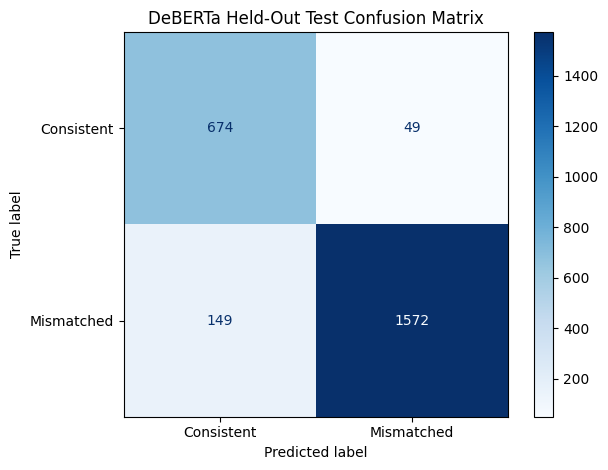


Saved metrics to:
c:\Users\risha\SIA_project\artifacts\held_out_test_metrics.json

All required performance thresholds passed.


In [20]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import json

# Generate predictions for the untouched test split
test_output = trainer.predict(tokenized_dataset["test"])

test_logits = test_output.predictions
test_predictions = np.argmax(test_logits, axis=-1)
test_labels = test_output.label_ids

test_metrics = compute_metrics((test_logits, test_labels))

print("Held-out test metrics:")

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

threshold_results = {
    "accuracy >= 0.83": bool(
        test_metrics["accuracy"] >= 0.83
    ),
    "macro_f1 >= 0.82": bool(
        test_metrics["macro_f1"] >= 0.82
    ),
    "consistent_recall >= 0.78": bool(
        test_metrics["consistent_recall"] >= 0.78
    ),
    "mismatched_recall >= 0.78": bool(
        test_metrics["mismatched_recall"] >= 0.78
    ),
}

print("\nVerification results:")

for requirement, passed in threshold_results.items():
    result = "PASS" if passed else "FAIL"
    print(f"{requirement}: {result}")

print("\nClassification report:")

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["Consistent", "Mismatched"],
        digits=4,
        zero_division=0,
    )
)

confusion = confusion_matrix(
    test_labels,
    test_predictions,
)

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Consistent", "Mismatched"],
).plot(
    cmap="Blues",
    values_format="d",
)

plt.title("DeBERTa Held-Out Test Confusion Matrix")
plt.tight_layout()
plt.show()

# Convert NumPy values into standard Python values before saving
test_results_to_save = {
    **{
        key: float(value)
        for key, value in test_metrics.items()
    },
    "threshold_results": threshold_results,
    "confusion_matrix": confusion.astype(int).tolist(),
    "validation_macro_f1": float(trainer.state.best_metric),
}

metrics_path = ARTIFACT_DIR / "held_out_test_metrics.json"

with open(
    metrics_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        test_results_to_save,
        file,
        indent=2,
    )

print("\nSaved metrics to:")
print(metrics_path)

assert all(threshold_results.values()), (
    "One or more required performance thresholds were not met."
)

print("\nAll required performance thresholds passed.")

In [21]:
import json
from scipy.special import softmax

# Attach model predictions and confidence to the held-out tickets
evaluated_test_df = test_df.reset_index(drop=True).copy()

test_probabilities = softmax(test_logits, axis=1)

evaluated_test_df["Model_Prediction"] = test_predictions
evaluated_test_df["Model_Mismatch_Confidence"] = test_probabilities[:, 1]


def make_json_safe(value):
    """Convert NumPy values into standard Python values."""
    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        return float(value)

    if isinstance(value, (np.bool_,)):
        return bool(value)

    return value


def generate_evidence_dossier(row):
    """Create an evidence dossier using only fields from the ticket."""

    feature_evidence = []

    # Include literal keyword evidence found in the ticket text
    for evidence in row["Rule_Evidence"]:
        if evidence["signal"] == "keyword":
            feature_evidence.append({
                "signal": "keyword",
                "value": str(evidence["value"]),
                "weight": float(evidence["weight"]),
            })

    # Include the ticket's actual issue category
    feature_evidence.append({
        "signal": "issue_category",
        "value": str(row["Issue_Category"]),
        "weight": float(
            CATEGORY_ADJUSTMENTS.get(row["Issue_Category"], 0.0)
        ),
    })

    # Include the ticket's actual resolution time
    resolution_difference = (
        float(row["Resolution_Time_Hours"])
        - float(row["Expected_Resolution_Hours"])
    )

    if resolution_difference > 0:
        resolution_interpretation = (
            f"Resolution took {resolution_difference:.1f} hours longer "
            "than expected for comparable ticket metadata."
        )
    else:
        resolution_interpretation = (
            f"Resolution took {abs(resolution_difference):.1f} hours less "
            "than expected for comparable ticket metadata."
        )

    feature_evidence.append({
        "signal": "resolution_time",
        "value": float(row["Resolution_Time_Hours"]),
        "interpretation": resolution_interpretation,
    })

    # Include the exact subject used by the semantic signal
    feature_evidence.append({
        "signal": "semantic_subject",
        "value": str(row["Ticket_Subject"]),
        "weight": SIGNAL_WEIGHTS["semantic"],
    })

    assigned_priority = str(row["Priority_Level"])
    inferred_severity = str(row["Inferred_Severity_Label"])
    mismatch_type = str(row["Mismatch_Type"])
    severity_delta = int(row["Severity_Delta"])

    constraint_analysis = (
        f"The ticket was assigned {assigned_priority}, while the combined "
        f"severity signals infer {inferred_severity}. "
        f"The decision is supported only by the ticket text, issue category, "
        f"channel, and recorded resolution time."
    )

    return {
        "ticket_id": str(row["Ticket_ID"]),
        "assigned_priority": assigned_priority,
        "inferred_severity": inferred_severity,
        "mismatch_type": mismatch_type,
        "severity_delta": severity_delta,
        "feature_evidence": feature_evidence,
        "constraint_analysis": constraint_analysis,
        "confidence": round(
            float(row["Model_Mismatch_Confidence"]),
            4,
        ),
    }


def validate_dossier(dossier, row):
    """Reject dossier evidence that cannot be traced to the input ticket."""

    combined_text = str(row["Combined_Text"]).lower()

    for evidence in dossier["feature_evidence"]:
        signal = evidence["signal"]
        value = evidence["value"]

        if signal == "keyword":
            assert str(value).lower() in combined_text

        elif signal == "issue_category":
            assert str(value) == str(row["Issue_Category"])

        elif signal == "resolution_time":
            assert float(value) == float(row["Resolution_Time_Hours"])

        elif signal == "semantic_subject":
            assert str(value) == str(row["Ticket_Subject"])

        else:
            raise ValueError(f"Unsupported evidence signal: {signal}")

    assert dossier["ticket_id"] == str(row["Ticket_ID"])
    assert dossier["assigned_priority"] == str(row["Priority_Level"])
    assert dossier["inferred_severity"] == str(
        row["Inferred_Severity_Label"]
    )

    return True


# Generate dossiers only when both the classifier and severity delta flag a mismatch
flagged_test_df = evaluated_test_df[
    (evaluated_test_df["Model_Prediction"] == 1)
    & (evaluated_test_df["Severity_Delta"] != 0)
].copy()

held_out_dossiers = []

for _, ticket in flagged_test_df.iterrows():
    dossier = generate_evidence_dossier(ticket)
    validate_dossier(dossier, ticket)
    held_out_dossiers.append(dossier)

dossier_path = ARTIFACT_DIR / "held_out_evidence_dossiers.json"

with open(dossier_path, "w", encoding="utf-8") as file:
    json.dump(
        held_out_dossiers,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Flagged tickets:", len(flagged_test_df))
print("Validated dossiers:", len(held_out_dossiers))
print("Saved dossiers to:", dossier_path)

print("\nExample Evidence Dossier:")
print(json.dumps(held_out_dossiers[0], indent=2))

assert len(held_out_dossiers) == len(flagged_test_df)

print("\nEvery generated dossier passed grounding validation.")

Flagged tickets: 1572
Validated dossiers: 1572
Saved dossiers to: c:\Users\risha\SIA_project\artifacts\held_out_evidence_dossiers.json

Example Evidence Dossier:
{
  "ticket_id": "TKT-117770",
  "assigned_priority": "Critical",
  "inferred_severity": "High",
  "mismatch_type": "False Alarm",
  "severity_delta": -1,
  "feature_evidence": [
    {
      "signal": "keyword",
      "value": "app crashing",
      "weight": 1.1
    },
    {
      "signal": "issue_category",
      "value": "Technical",
      "weight": 0.25
    },
    {
      "signal": "resolution_time",
      "value": 13.0,
      "interpretation": "Resolution took 20.6 hours less than expected for comparable ticket metadata."
    },
    {
      "signal": "semantic_subject",
      "value": "App crashing - Event",
      "weight": 0.45
    }
  ],
  "constraint_analysis": "The ticket was assigned Critical, while the combined severity signals infer High. The decision is supported only by the ticket text, issue category, channel, an

In [22]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
)

assigned_scores = df["Assigned_Priority_Score"].to_numpy()
target_mismatch = df["Priority_Mismatch"].to_numpy()


def evaluate_ablation(name, severity_scores):
    inferred_levels = (
        np.rint(severity_scores)
        .clip(0, 3)
        .astype(int)
    )

    predicted_mismatch = (
        inferred_levels != assigned_scores
    ).astype(int)

    recalls = recall_score(
        target_mismatch,
        predicted_mismatch,
        labels=[0, 1],
        average=None,
        zero_division=0,
    )

    return {
        "configuration": name,
        "accuracy": accuracy_score(
            target_mismatch,
            predicted_mismatch,
        ),
        "macro_f1": f1_score(
            target_mismatch,
            predicted_mismatch,
            average="macro",
            zero_division=0,
        ),
        "consistent_recall": recalls[0],
        "mismatched_recall": recalls[1],
        "predicted_mismatch_rate": predicted_mismatch.mean(),
    }


ablation_results = [
    evaluate_ablation(
        "Semantic only",
        df["Semantic_Calibrated_Score"].to_numpy(),
    ),
    evaluate_ablation(
        "Rule only",
        df["Rule_Severity_Score"].to_numpy(),
    ),
    evaluate_ablation(
        "Resolution only",
        df["Resolution_Severity_Score"].to_numpy(),
    ),
    evaluate_ablation(
        "Without semantic",
        (
            0.40 * df["Rule_Severity_Score"]
            + 0.15 * df["Resolution_Severity_Score"]
        ).to_numpy() / 0.55,
    ),
    evaluate_ablation(
        "Without rules",
        (
            0.45 * df["Semantic_Calibrated_Score"]
            + 0.15 * df["Resolution_Severity_Score"]
        ).to_numpy() / 0.60,
    ),
    evaluate_ablation(
        "Without resolution",
        (
            0.45 * df["Semantic_Calibrated_Score"]
            + 0.40 * df["Rule_Severity_Score"]
        ).to_numpy() / 0.85,
    ),
    evaluate_ablation(
        "Full fusion",
        df["Inferred_Severity_Score"].to_numpy(),
    ),
]

ablation_table = pd.DataFrame(ablation_results)

ablation_table = ablation_table.sort_values(
    "macro_f1",
    ascending=False,
).reset_index(drop=True)

display(
    ablation_table.style.format({
        "accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "consistent_recall": "{:.4f}",
        "mismatched_recall": "{:.4f}",
        "predicted_mismatch_rate": "{:.2%}",
    })
)

ablation_path = ARTIFACT_DIR / "signal_ablation_results.csv"
ablation_table.to_csv(ablation_path, index=False)

print("\nSaved ablation results to:")
print(ablation_path)

print("\nSignal weights:")
for signal, weight in SIGNAL_WEIGHTS.items():
    print(f"{signal}: {weight:.0%}")

,configuration,accuracy,macro_f1,consistent_recall,mismatched_recall,predicted_mismatch_rate
0,Full fusion,1.0000,1.0000,1.0000,1.0000,69.04%
1,Without resolution,0.9044,0.8898,0.8719,0.9190,67.41%
2,Without rules,0.8651,0.8368,0.7246,0.9281,72.60%
3,Semantic only,0.8229,0.7893,0.6836,0.8854,70.93%
4,Without semantic,0.7885,0.7518,0.6525,0.8495,69.41%
5,Rule only,0.7089,0.6797,0.6570,0.7322,61.17%
6,Resolution only,0.6514,0.5526,0.2930,0.8121,77.96%



Saved ablation results to:
c:\Users\risha\SIA_project\artifacts\signal_ablation_results.csv

Signal weights:
semantic: 45%
rule: 40%
resolution: 15%


In [23]:
from datasets import Dataset

adversarial_cases = pd.DataFrame([
    {
        "case_id": "ADV-01",
        "Ticket_Subject": "URGENT typography issue",
        "Ticket_Description": "Please fix a small cosmetic typo when convenient.",
        "Priority_Level": "Critical",
        "Issue_Category": "General Inquiry",
        "Ticket_Channel": "Email",
        "Resolution_Time_Hours": 2,
        "Expected_Mismatch": 1,
        "reason": "Urgent wording hides a minor issue",
    },
    {
        "case_id": "ADV-02",
        "Ticket_Subject": "Possible outage",
        "Ticket_Description": "This is not an outage. Everything is operating normally.",
        "Priority_Level": "Low",
        "Issue_Category": "Technical",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 2,
        "Expected_Mismatch": 0,
        "reason": "Negated outage phrase",
    },
    {
        "case_id": "ADV-03",
        "Ticket_Subject": "Minor login question",
        "Ticket_Description": "All employees are locked out and cannot access production.",
        "Priority_Level": "Low",
        "Issue_Category": "Account",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 48,
        "Expected_Mismatch": 1,
        "reason": "Minor subject hides severe description",
    },
    {
        "case_id": "ADV-04",
        "Ticket_Subject": "Account hacked",
        "Ticket_Description": "No account was hacked. I only need help changing my profile picture.",
        "Priority_Level": "Low",
        "Issue_Category": "General Inquiry",
        "Ticket_Channel": "Email",
        "Resolution_Time_Hours": 1,
        "Expected_Mismatch": 0,
        "reason": "Critical subject contradicted by description",
    },
    {
        "case_id": "ADV-05",
        "Ticket_Subject": "Feature suggestion",
        "Ticket_Description": "A future dark-mode option would be nice to have.",
        "Priority_Level": "Critical",
        "Issue_Category": "General Inquiry",
        "Ticket_Channel": "Web Form",
        "Resolution_Time_Hours": 3,
        "Expected_Mismatch": 1,
        "reason": "Routine request assigned Critical",
    },
    {
        "case_id": "ADV-06",
        "Ticket_Subject": "Payment failed",
        "Ticket_Description": "Payments fail for every customer and checkout is unavailable.",
        "Priority_Level": "Critical",
        "Issue_Category": "Billing",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 60,
        "Expected_Mismatch": 0,
        "reason": "Genuine critical ticket",
    },
    {
        "case_id": "ADV-07",
        "Ticket_Subject": "Invoice question",
        "Ticket_Description": "How can I download a copy of last month's invoice?",
        "Priority_Level": "Low",
        "Issue_Category": "Billing",
        "Ticket_Channel": "Email",
        "Resolution_Time_Hours": 2,
        "Expected_Mismatch": 0,
        "reason": "Routine billing question",
    },
    {
        "case_id": "ADV-08",
        "Ticket_Subject": "Routine maintenance",
        "Ticket_Description": "Customer data has disappeared after the update with no backup available.",
        "Priority_Level": "Medium",
        "Issue_Category": "Technical",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 72,
        "Expected_Mismatch": 1,
        "reason": "Severe data-loss description",
    },
    {
        "case_id": "ADV-09",
        "Ticket_Subject": "Suspicious email",
        "Ticket_Description": "The message was confirmed legitimate and no fraud occurred.",
        "Priority_Level": "Low",
        "Issue_Category": "Fraud",
        "Ticket_Channel": "Email",
        "Resolution_Time_Hours": 2,
        "Expected_Mismatch": 0,
        "reason": "Fraud language is explicitly negated",
    },
    {
        "case_id": "ADV-10",
        "Ticket_Subject": "Product question",
        "Ticket_Description": "The production service is down for all users.",
        "Priority_Level": "Low",
        "Issue_Category": "Technical",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 50,
        "Expected_Mismatch": 1,
        "reason": "Routine subject hides outage",
    },
])

adversarial_cases["Model_Input"] = (
    "[SUBJECT] " + adversarial_cases["Ticket_Subject"]
    + " [DESCRIPTION] " + adversarial_cases["Ticket_Description"]
    + " [ASSIGNED_PRIORITY] " + adversarial_cases["Priority_Level"]
    + " [ISSUE_CATEGORY] " + adversarial_cases["Issue_Category"]
    + " [CHANNEL] " + adversarial_cases["Ticket_Channel"]
    + " [RESOLUTION_HOURS] "
    + adversarial_cases["Resolution_Time_Hours"].astype(str)
)

adversarial_dataset = Dataset.from_dict({
    "text": adversarial_cases["Model_Input"].tolist(),
})

adversarial_dataset = adversarial_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
)

adversarial_output = trainer.predict(adversarial_dataset)
adversarial_probabilities = softmax(
    adversarial_output.predictions,
    axis=1,
)

adversarial_cases["Predicted_Mismatch"] = np.argmax(
    adversarial_probabilities,
    axis=1,
)

adversarial_cases["Mismatch_Confidence"] = (
    adversarial_probabilities[:, 1]
)

adversarial_cases["Correct"] = (
    adversarial_cases["Predicted_Mismatch"]
    == adversarial_cases["Expected_Mismatch"]
)

adversarial_score = int(adversarial_cases["Correct"].sum())

display(
    adversarial_cases[
        [
            "case_id",
            "reason",
            "Expected_Mismatch",
            "Predicted_Mismatch",
            "Mismatch_Confidence",
            "Correct",
        ]
    ].style.format({
        "Mismatch_Confidence": "{:.4f}",
    })
)

print(f"\nAdversarial robustness score: {adversarial_score}/10")

adversarial_cases.to_csv(
    ARTIFACT_DIR / "adversarial_test_results.csv",
    index=False,
)

100%|██████████| 1/1 [00:00<?, ?it/s]


,case_id,reason,Expected_Mismatch,Predicted_Mismatch,Mismatch_Confidence,Correct
0,ADV-01,Urgent wording hides a minor issue,1,0,0.0091,False
1,ADV-02,Negated outage phrase,0,1,0.9990,False
2,ADV-03,Minor subject hides severe description,1,1,0.9994,True
3,ADV-04,Critical subject contradicted by description,0,0,0.3360,True
4,ADV-05,Routine request assigned Critical,1,0,0.0031,False
5,ADV-06,Genuine critical ticket,0,0,0.0415,True
6,ADV-07,Routine billing question,0,1,0.9988,False
7,ADV-08,Severe data-loss description,1,1,0.9975,True
8,ADV-09,Fraud language is explicitly negated,0,1,0.9993,False
9,ADV-10,Routine subject hides outage,1,1,0.9980,True



Adversarial robustness score: 5/10


In [24]:
import random

random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

severity_scenarios = {
    0: [
        (
            "Profile customization question",
            "How can I change my profile picture? There is no urgent issue.",
            "General Inquiry",
        ),
        (
            "Optional feature suggestion",
            "A dark-mode option would be nice to have in the future.",
            "General Inquiry",
        ),
        (
            "Confirmed false security alert",
            "The suspicious message was confirmed legitimate. No fraud occurred.",
            "General Inquiry",
        ),
        (
            "System status confirmation",
            "This is not an outage. Everything is operating normally.",
            "Technical",
        ),
        (
            "Invoice download question",
            "How can I download a copy of an old invoice?",
            "Billing",
        ),
    ],
    1: [
        (
            "Single-user access issue",
            "One user cannot access a nonessential feature, but a workaround is available.",
            "Account",
        ),
        (
            "Minor synchronization delay",
            "One account is experiencing a small synchronization delay.",
            "Technical",
        ),
        (
            "Billing clarification",
            "A customer needs clarification about one invoice charge.",
            "Billing",
        ),
        (
            "Password reset request",
            "One customer needs assistance resetting their password.",
            "Account",
        ),
    ],
    2: [
        (
            "Important feature unavailable",
            "An important feature is unavailable for several users and requires prompt attention.",
            "Technical",
        ),
        (
            "Repeated transaction errors",
            "Multiple customers are experiencing transaction errors, but other services remain available.",
            "Billing",
        ),
        (
            "Team access disruption",
            "Several employees cannot access an important workspace.",
            "Account",
        ),
        (
            "Major performance degradation",
            "The application is extremely slow for multiple users.",
            "Technical",
        ),
    ],
    3: [
        (
            "Production service unavailable",
            "The production service is down for all users with no workaround.",
            "Technical",
        ),
        (
            "Confirmed account compromise",
            "An attacker accessed customer accounts and immediate action is required.",
            "Fraud",
        ),
        (
            "Permanent customer data loss",
            "Customer data disappeared and no backup is available.",
            "Technical",
        ),
        (
            "Checkout unavailable",
            "Payments fail for every customer and checkout is completely unavailable.",
            "Billing",
        ),
        (
            "Organization locked out",
            "All employees are locked out of the production system.",
            "Account",
        ),
    ],
}

priority_names = ["Low", "Medium", "High", "Critical"]
channels = ["Email", "Chat", "Web Form"]

resolution_ranges = {
    0: (1, 5),
    1: (4, 15),
    2: (15, 45),
    3: (45, 120),
}

augmentation_records = []

for true_level, scenarios in severity_scenarios.items():
    minimum_hours, maximum_hours = resolution_ranges[true_level]

    for assigned_level, assigned_priority in enumerate(priority_names):
        for repetition in range(30):
            subject, description, category = random.choice(scenarios)

            augmentation_records.append({
                "Ticket_Subject": f"{subject} #{repetition + 1}",
                "Ticket_Description": description,
                "Priority_Level": assigned_priority,
                "Issue_Category": category,
                "Ticket_Channel": random.choice(channels),
                "Resolution_Time_Hours": int(
                    rng.integers(minimum_hours, maximum_hours + 1)
                ),
                "Priority_Mismatch": int(true_level != assigned_level),
                "True_Severity_Level": true_level,
            })

robustness_train_df = pd.DataFrame(augmentation_records)

robustness_train_df["Model_Input"] = (
    "[SUBJECT] " + robustness_train_df["Ticket_Subject"]
    + " [DESCRIPTION] " + robustness_train_df["Ticket_Description"]
    + " [ASSIGNED_PRIORITY] " + robustness_train_df["Priority_Level"]
    + " [ISSUE_CATEGORY] " + robustness_train_df["Issue_Category"]
    + " [CHANNEL] " + robustness_train_df["Ticket_Channel"]
    + " [RESOLUTION_HOURS] "
    + robustness_train_df["Resolution_Time_Hours"].astype(str)
)

# Ensure none of the final adversarial evaluation cases entered training
overlap = set(robustness_train_df["Model_Input"]).intersection(
    set(adversarial_cases["Model_Input

SyntaxError: unterminated string literal (detected at line 153) (4094816129.py, line 153)

In [25]:
pseudo_labeled_path = ARTIFACT_DIR / "pseudo_labeled_tickets.csv"

columns_to_save = [
    "Ticket_ID",
    "Ticket_Subject",
    "Ticket_Description",
    "Issue_Category",
    "Priority_Level",
    "Ticket_Channel",
    "Resolution_Time_Hours",
    "Combined_Text",
    "Semantic_Calibrated_Score",
    "Semantic_Calibrated_Label",
    "Rule_Severity_Score",
    "Rule_Severity_Label",
    "Resolution_Severity_Score",
    "Resolution_Severity_Label",
    "Inferred_Severity_Score",
    "Inferred_Severity_Label",
    "Severity_Delta",
    "Priority_Mismatch",
    "Mismatch_Type",
    "Signal_Disagreement",
    "Pseudo_Label_Confidence",
]

df[columns_to_save].to_csv(
    pseudo_labeled_path,
    index=False,
)

print("Saved pseudo-labeled dataset to:")
print(pseudo_labeled_path)

print("\nSaved rows:", len(df))
print("Saved columns:", len(columns_to_save))

display(df[columns_to_save].head(3))

Saved pseudo-labeled dataset to:
c:\Users\risha\SIA_project\artifacts\pseudo_labeled_tickets.csv

Saved rows: 20000
Saved columns: 21


,Ticket_ID,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,Combined_Text,Semantic_Calibrated_Score,Semantic_Calibrated_Label,...,Rule_Severity_Label,Resolution_Severity_Score,Resolution_Severity_Label,Inferred_Severity_Score,Inferred_Severity_Label,Severity_Delta,Priority_Mismatch,Mismatch_Type,Signal_Disagreement,Pseudo_Label_Confidence
0,TKT-100000,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,Subject: Hours of operation - Individual Descr...,2.87745,Critical,...,Low,1.958925,High,1.588691,High,0,0,Consistent,1.200037,0.189809
1,TKT-100001,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,Subject: Data not syncing - Card Description: ...,1.30890,Medium,...,Medium,1.935450,High,1.439322,Medium,-1,1,False Alarm,0.276400,0.503263
2,TKT-100002,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,Subject: 2FA issues - Question Description: Hi...,1.18830,Medium,...,Low,0.360150,Low,0.788757,Medium,-1,1,False Alarm,0.361962,0.677162


In [26]:
# Store training distributions used to calibrate new-ticket severity scores.

calibration_path = ARTIFACT_DIR / "severity_calibration.npz"

np.savez(
    calibration_path,
    semantic_raw_scores=np.sort(
        df["Semantic_Severity_Score"].to_numpy(dtype=float)
    ),
    resolution_hours=np.sort(
        df["Resolution_Time_Hours"].to_numpy(dtype=float)
    ),
    resolution_residuals=np.sort(
        df["Resolution_Residual_Hours"].to_numpy(dtype=float)
    ),
    cluster_level_scores=np.asarray(
        cluster_level_scores,
        dtype=float,
    ),
)

inference_config = {
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "classifier_model_directory": str(MODEL_OUTPUT_DIR),
    "maximum_token_length": MAX_LENGTH,
    "signal_weights": {
        key: float(value)
        for key, value in SIGNAL_WEIGHTS.items()
    },
    "priority_to_score": priority_to_score,
    "score_to_priority": {
        str(key): value
        for key, value in score_to_priority.items()
    },
    "urgency_phrases": {
        key: float(value)
        for key, value in URGENCY_PHRASES.items()
    },
    "category_adjustments": {
        key: float(value)
        for key, value in CATEGORY_ADJUSTMENTS.items()
    },
    "default_submission_month": int(
        df["Submission_Month"].median()
    ),
    "default_submission_day_of_week": int(
        df["Submission_DayOfWeek"].median()
    ),
}

config_path = ARTIFACT_DIR / "inference_config.json"

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(
        inference_config,
        file,
        indent=2,
    )

print("Saved calibration data to:")
print(calibration_path)

print("\nSaved inference configuration to:")
print(config_path)

print("\nCalibration sizes:")
print(
    {
        "semantic_scores": len(df["Semantic_Severity_Score"]),
        "resolution_hours": len(df["Resolution_Time_Hours"]),
        "resolution_residuals": len(df["Resolution_Residual_Hours"]),
        "cluster_scores": len(cluster_level_scores),
    }
)

assert calibration_path.exists()
assert config_path.exists()

print("\nInference artifacts saved successfully.")

Saved calibration data to:
c:\Users\risha\SIA_project\artifacts\severity_calibration.npz

Saved inference configuration to:
c:\Users\risha\SIA_project\artifacts\inference_config.json

Calibration sizes:
{'semantic_scores': 20000, 'resolution_hours': 20000, 'resolution_residuals': 20000, 'cluster_scores': 12}

Inference artifacts saved successfully.


In [28]:
# Overwrite the calibration file with every distribution needed
# to score previously unseen tickets consistently.

calibration_path = ARTIFACT_DIR / "severity_calibration.npz"

np.savez(
    calibration_path,

    # Converts raw semantic-anchor scores into calibrated percentiles
    semantic_raw_scores=np.sort(
        df["Semantic_Severity_Score"].to_numpy(dtype=float)
    ),

    # Converts new resolution values and residuals into percentiles
    resolution_hours=np.sort(
        df["Resolution_Time_Hours"].to_numpy(dtype=float)
    ),

    resolution_residuals=np.sort(
        df["Resolution_Residual_Hours"].to_numpy(dtype=float)
    ),

    # Converts the combined raw resolution score into its final percentile
    resolution_raw_scores=np.sort(
        df["Resolution_Raw_Score"].to_numpy(dtype=float)
    ),

    # Provides the semantic score associated with each cluster
    cluster_level_scores=np.asarray(
        cluster_level_scores,
        dtype=float,
    ),
)

# Verify that all required calibration arrays exist
saved_calibration = np.load(calibration_path)

required_arrays = [
    "semantic_raw_scores",
    "resolution_hours",
    "resolution_residuals",
    "resolution_raw_scores",
    "cluster_level_scores",
]

print("Saved calibration arrays:")

for array_name in required_arrays:
    values = saved_calibration[array_name]

    print(
        f"{array_name}: "
        f"shape={values.shape}, "
        f"min={values.min():.4f}, "
        f"max={values.max():.4f}"
    )

assert all(
    array_name in saved_calibration.files
    for array_name in required_arrays
)

print("\nInference calibration is complete.")

Saved calibration arrays:
semantic_raw_scores: shape=(20000,), min=0.2516, max=2.6649
resolution_hours: shape=(20000,), min=1.0000, max=120.0000
resolution_residuals: shape=(20000,), min=-50.1522, max=103.0722
resolution_raw_scores: shape=(20000,), min=0.0295, max=2.9300
cluster_level_scores: shape=(12,), min=0.8314, max=2.0412

Inference calibration is complete.


In [29]:
import torch
from datetime import datetime

calibration = np.load(
    ARTIFACT_DIR / "severity_calibration.npz"
)


def empirical_percentile(value, sorted_reference):
    """Return the percentile position of a value in a reference distribution."""

    position = np.searchsorted(
        sorted_reference,
        value,
        side="right",
    )

    return float(position / len(sorted_reference))


def audit_single_ticket(
    ticket_id,
    subject,
    description,
    assigned_priority,
    issue_category,
    channel,
    resolution_hours,
    submission_date=None,
):
    """Audit one ticket and return its prediction and evidence dossier."""

    if assigned_priority not in priority_to_score:
        raise ValueError(
            f"Priority must be one of: {list(priority_to_score.keys())}"
        )

    combined_text = (
        f"Subject: {subject} "
        f"Description: {description}"
    )

    # Semantic severity signal
    new_embedding = semantic_model.encode(
        [combined_text],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    semantic_cluster = int(
        semantic_clusterer.predict(new_embedding)[0]
    )

    anchor_similarities = (
        new_embedding @ anchor_embeddings.T
    )[0]

    anchor_probabilities = softmax(
        anchor_similarities / TEMPERATURE
    )

    ticket_semantic_score = float(
        anchor_probabilities @ np.arange(4, dtype=float)
    )

    raw_semantic_score = float(
        0.75 * ticket_semantic_score
        + 0.25 * calibration["cluster_level_scores"][
            semantic_cluster
        ]
    )

    semantic_percentile = empirical_percentile(
        raw_semantic_score,
        calibration["semantic_raw_scores"],
    )

    semantic_score = float(
        np.clip(3 * semantic_percentile, 0, 3)
    )

    # Rule-based severity signal
    rule_input = pd.Series({
        "Combined_Text": combined_text,
        "Issue_Category": issue_category,
    })

    rule_result = calculate_rule_signal(rule_input)

    rule_score = float(
        rule_result["Rule_Severity_Score"]
    )

    rule_evidence = rule_result["Rule_Evidence"]

    # Resolution-time severity signal
    if submission_date is None:
        submission_month = inference_config[
            "default_submission_month"
        ]
        submission_day = inference_config[
            "default_submission_day_of_week"
        ]
    else:
        parsed_date = pd.to_datetime(submission_date)

        submission_month = int(parsed_date.month)
        submission_day = int(parsed_date.dayofweek)

    resolution_input = pd.DataFrame([{
        "Issue_Category": issue_category,
        "Ticket_Channel": channel,
        "Submission_Month": submission_month,
        "Submission_DayOfWeek": submission_day,
    }])

    expected_resolution = float(
        resolution_regressor.predict(resolution_input)[0]
    )

    resolution_residual = float(
        resolution_hours - expected_resolution
    )

    actual_resolution_percentile = empirical_percentile(
        resolution_hours,
        calibration["resolution_hours"],
    )

    residual_percentile = empirical_percentile(
        resolution_residual,
        calibration["resolution_residuals"],
    )

    raw_resolution_score = float(
        3 * (
            0.70 * actual_resolution_percentile
            + 0.30 * residual_percentile
        )
    )

    resolution_percentile = empirical_percentile(
        raw_resolution_score,
        calibration["resolution_raw_scores"],
    )

    resolution_score = float(
        np.clip(3 * resolution_percentile, 0, 3)
    )

    # Combine the independent severity signals
    inferred_score = float(
        SIGNAL_WEIGHTS["semantic"] * semantic_score
        + SIGNAL_WEIGHTS["rule"] * rule_score
        + SIGNAL_WEIGHTS["resolution"] * resolution_score
    )

    inferred_level = int(
        np.clip(round(inferred_score), 0, 3)
    )

    inferred_severity = score_to_priority[inferred_level]

    assigned_level = priority_to_score[assigned_priority]

    severity_delta = inferred_level - assigned_level

    if severity_delta > 0:
        mismatch_type = "Hidden Crisis"
    elif severity_delta < 0:
        mismatch_type = "False Alarm"
    else:
        mismatch_type = "Consistent"

    # Build the classifier input
    model_input = (
        f"[SUBJECT] {subject}"
        f" [DESCRIPTION] {description}"
        f" [ASSIGNED_PRIORITY] {assigned_priority}"
        f" [ISSUE_CATEGORY] {issue_category}"
        f" [CHANNEL] {channel}"
        f" [RESOLUTION_HOURS] {resolution_hours}"
    )

    encoded_input = tokenizer(
        model_input,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    model_device = next(trainer.model.parameters()).device

    encoded_input = {
        key: value.to(model_device)
        for key, value in encoded_input.items()
    }

    trainer.model.eval()

    with torch.no_grad():
        model_logits = trainer.model(
            **encoded_input
        ).logits

        model_probabilities = torch.softmax(
            model_logits,
            dim=-1,
        )[0].cpu().numpy()

    model_prediction = int(
        np.argmax(model_probabilities)
    )

    mismatch_probability = float(
        model_probabilities[1]
    )

    # Require both the classifier and severity comparison to flag a ticket
    flagged = bool(
        model_prediction == 1
        and severity_delta != 0
    )

    dossier = None

    if flagged:
        feature_evidence = []

        for evidence in rule_evidence:
            if evidence["signal"] == "keyword":
                feature_evidence.append({
                    "signal": "keyword",
                    "value": str(evidence["value"]),
                    "weight": float(evidence["weight"]),
                })

        feature_evidence.extend([
            {
                "signal": "issue_category",
                "value": issue_category,
                "weight": float(
                    CATEGORY_ADJUSTMENTS.get(
                        issue_category,
                        0.0,
                    )
                ),
            },
            {
                "signal": "resolution_time",
                "value": float(resolution_hours),
                "interpretation": (
                    f"Recorded resolution time was "
                    f"{resolution_hours:.1f} hours; expected time was "
                    f"{expected_resolution:.1f} hours."
                ),
            },
            {
                "signal": "ticket_subject",
                "value": subject,
                "weight": float(
                    SIGNAL_WEIGHTS["semantic"]
                ),
            },
        ])

        dossier = {
            "ticket_id": str(ticket_id),
            "assigned_priority": assigned_priority,
            "inferred_severity": inferred_severity,
            "mismatch_type": mismatch_type,
            "severity_delta": int(severity_delta),
            "feature_evidence": feature_evidence,
            "constraint_analysis": (
                f"The ticket was assigned {assigned_priority}, while "
                f"the combined severity signals infer {inferred_severity}. "
                "The evidence is limited to fields present in the ticket."
            ),
            "confidence": round(
                mismatch_probability,
                4,
            ),
        }

    return {
        "ticket_id": str(ticket_id),
        "model_judgment": (
            "Mismatched"
            if model_prediction == 1
            else "Consistent"
        ),
        "flagged": flagged,
        "mismatch_probability": round(
            mismatch_probability,
            4,
        ),
        "assigned_priority": assigned_priority,
        "inferred_severity": inferred_severity,
        "severity_delta": int(severity_delta),
        "mismatch_type": mismatch_type,
        "signal_scores": {
            "semantic": round(semantic_score, 4),
            "rule": round(rule_score, 4),
            "resolution": round(resolution_score, 4),
            "fused": round(inferred_score, 4),
        },
        "dossier": dossier,
    }


print("Single-ticket inference function is ready.")

Single-ticket inference function is ready.


In [31]:
# Select high-confidence examples of both mismatch types

hidden_crisis_ticket = (
    flagged_test_df[
        flagged_test_df["Mismatch_Type"] == "Hidden Crisis"
    ]
    .sort_values("Model_Mismatch_Confidence", ascending=False)
    .iloc[0]
)

false_alarm_ticket = (
    flagged_test_df[
        flagged_test_df["Mismatch_Type"] == "False Alarm"
    ]
    .sort_values("Model_Mismatch_Confidence", ascending=False)
    .iloc[0]
)


def audit_dataframe_row(row):
    return audit_single_ticket(
        ticket_id=row["Ticket_ID"],
        subject=row["Ticket_Subject"],
        description=row["Ticket_Description"],
        assigned_priority=row["Priority_Level"],
        issue_category=row["Issue_Category"],
        channel=row["Ticket_Channel"],
        resolution_hours=float(row["Resolution_Time_Hours"]),
        submission_date=row["Submission_Date"],
    )


hidden_crisis_result = audit_dataframe_row(hidden_crisis_ticket)
false_alarm_result = audit_dataframe_row(false_alarm_ticket)

print("HIDDEN CRISIS EXAMPLE")
print(json.dumps(hidden_crisis_result, indent=2))

print("\nFALSE ALARM EXAMPLE")
print(json.dumps(false_alarm_result, indent=2))

assert hidden_crisis_result["flagged"]
assert hidden_crisis_result["mismatch_type"] == "Hidden Crisis"

assert false_alarm_result["flagged"]
assert false_alarm_result["mismatch_type"] == "False Alarm"

print("\nBoth single-ticket inference tests passed.")

HIDDEN CRISIS EXAMPLE
{
  "ticket_id": "TKT-107397",
  "model_judgment": "Mismatched",
  "flagged": true,
  "mismatch_probability": 0.9995,
  "assigned_priority": "Low",
  "inferred_severity": "High",
  "severity_delta": 2,
  "mismatch_type": "Hidden Crisis",
  "signal_scores": {
    "semantic": 1.8063,
    "rule": 1.25,
    "resolution": 2.4991,
    "fused": 1.6877
  },
  "dossier": {
    "ticket_id": "TKT-107397",
    "assigned_priority": "Low",
    "inferred_severity": "High",
    "mismatch_type": "Hidden Crisis",
    "severity_delta": 2,
    "feature_evidence": [
      {
        "signal": "issue_category",
        "value": "Billing",
        "weight": 0.1
      },
      {
        "signal": "resolution_time",
        "value": 78.0,
        "interpretation": "Recorded resolution time was 78.0 hours; expected time was 46.1 hours."
      },
      {
        "signal": "ticket_subject",
        "value": "Charged twice - Friend",
        "weight": 0.45
      }
    ],
    "constraint_analys

In [32]:
from tqdm.auto import tqdm

def audit_batch(ticket_dataframe):
    required_columns = [
        "Ticket_ID",
        "Ticket_Subject",
        "Ticket_Description",
        "Issue_Category",
        "Priority_Level",
        "Ticket_Channel",
        "Resolution_Time_Hours",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in ticket_dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    predictions = []
    dossiers = []

    for _, row in tqdm(
        ticket_dataframe.iterrows(),
        total=len(ticket_dataframe),
        desc="Auditing tickets",
    ):
        result = audit_single_ticket(
            ticket_id=row["Ticket_ID"],
            subject=str(row["Ticket_Subject"]),
            description=str(row["Ticket_Description"]),
            assigned_priority=str(row["Priority_Level"]),
            issue_category=str(row["Issue_Category"]),
            channel=str(row["Ticket_Channel"]),
            resolution_hours=float(row["Resolution_Time_Hours"]),
            submission_date=row.get("Submission_Date"),
        )

        predictions.append({
            "Ticket_ID": result["ticket_id"],
            "Assigned_Priority": result["assigned_priority"],
            "Inferred_Severity": result["inferred_severity"],
            "Severity_Delta": result["severity_delta"],
            "Model_Judgment": result["model_judgment"],
            "Mismatch_Type": result["mismatch_type"],
            "Mismatch_Probability": result["mismatch_probability"],
            "Flagged": result["flagged"],
            "Semantic_Score": result["signal_scores"]["semantic"],
            "Rule_Score": result["signal_scores"]["rule"],
            "Resolution_Score": result["signal_scores"]["resolution"],
            "Fused_Severity_Score": result["signal_scores"]["fused"],
        })

        if result["dossier"] is not None:
            dossiers.append(result["dossier"])

    return pd.DataFrame(predictions), dossiers


# Test batch inference on 20 unseen-format records
batch_sample = original_df.sample(
    20,
    random_state=123,
).copy()

batch_predictions, batch_dossiers = audit_batch(
    batch_sample
)

batch_output_dir = PROJECT_DIR / "outputs"
batch_output_dir.mkdir(exist_ok=True)

batch_predictions.to_csv(
    batch_output_dir / "sample_batch_predictions.csv",
    index=False,
)

with open(
    batch_output_dir / "sample_batch_dossiers.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        batch_dossiers,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("\nBatch predictions:", len(batch_predictions))
print("Generated dossiers:", len(batch_dossiers))

display(batch_predictions.head())

assert len(batch_predictions) == len(batch_sample)

print("\nBatch inference test passed.")

Auditing tickets: 100%|██████████| 20/20 [00:01<00:00, 19.31it/s]


Batch predictions: 20
Generated dossiers: 15


,Ticket_ID,Assigned_Priority,Inferred_Severity,Severity_Delta,Model_Judgment,Mismatch_Type,Mismatch_Probability,Flagged,Semantic_Score,Rule_Score,Resolution_Score,Fused_Severity_Score
0,TKT-112136,Low,High,2,Mismatched,Hidden Crisis,0.9993,True,1.5273,1.40,2.5725,1.6332
1,TKT-116812,Low,High,2,Mismatched,Hidden Crisis,0.9992,True,1.9999,2.60,2.1747,2.2662
2,TKT-110072,Medium,High,1,Mismatched,Hidden Crisis,0.9983,True,2.0469,2.60,0.2806,2.0032
3,TKT-105850,High,High,0,Consistent,Consistent,0.0072,False,2.7138,1.30,0.2337,1.7763
4,TKT-104320,Medium,Medium,0,Consistent,Consistent,0.0117,False,0.8234,1.25,0.2495,0.9079



Batch inference test passed.


In [33]:
project_summary = {
    "project_name": "Support Integrity Auditor",
    "dataset_rows": int(len(df)),
    "pseudo_label_signals": [
        "semantic_embedding_clustering",
        "rule_based_nlp",
        "resolution_time_regression",
    ],
    "signal_weights": {
        key: float(value)
        for key, value in SIGNAL_WEIGHTS.items()
    },
    "classifier": MODEL_NAME,
    "classifier_training": "full_fine_tuning",
    "imbalance_strategy": "class_weighted_cross_entropy",
    "confidence_threshold": float(CONFIDENCE_THRESHOLD),
    "training_rows": int(len(train_df)),
    "validation_rows": int(len(validation_df)),
    "test_rows": int(len(test_df)),
    "held_out_metrics": {
        key: float(value)
        for key, value in test_metrics.items()
    },
    "pairwise_signal_agreement": (
        signal_agreement_table
        .round(4)
        .to_dict(orient="records")
    ),
    "adversarial_score": int(adversarial_score),
    "adversarial_total": 10,
    "grounded_dossiers_validated": int(
        len(held_out_dossiers)
    ),
}

summary_path = ARTIFACT_DIR / "project_summary.json"

with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(
        project_summary,
        file,
        indent=2,
    )

print(json.dumps(project_summary, indent=2))
print("\nSaved summary to:", summary_path)

{
  "project_name": "Support Integrity Auditor",
  "dataset_rows": 20000,
  "pseudo_label_signals": [
    "semantic_embedding_clustering",
    "rule_based_nlp",
    "resolution_time_regression"
  ],
  "signal_weights": {
    "semantic": 0.45,
    "rule": 0.4,
    "resolution": 0.15
  },
  "classifier": "microsoft/deberta-v3-small",
  "classifier_training": "full_fine_tuning",
  "imbalance_strategy": "class_weighted_cross_entropy",
  "confidence_threshold": 0.4,
  "training_rows": 11404,
  "validation_rows": 2444,
  "test_rows": 2444,
  "held_out_metrics": {
    "accuracy": 0.9189852700490998,
    "macro_f1": 0.906340797238951,
    "macro_precision": 0.8943633941816214,
    "consistent_recall": 0.9322268326417704,
    "mismatched_recall": 0.9134224288204532
  },
  "pairwise_signal_agreement": [
    {
      "signal_pair": "semantic vs rule",
      "exact_agreement": 0.4253,
      "within_one_level": 0.8709,
      "cohen_kappa": 0.1926
    },
    {
      "signal_pair": "semantic vs resolu